# Red Team Lite – Controlled Adversary Simulation (Lab Only)

# Cybersecurity Security Assessment Report

**Author:** Dale Murphy  
**Project Type:** Red Team / Blue Team Simulation  
**Tools Used:** Nmap, TryHackMe, Python, SIEM Analysis  
**Date:** (3/9/2026)

---

## Table of Contents
1. Project Overview
2. Scope & Rules of Engagement
3. Deliverables
4. 20-Day Plan
5. Environment Setup
6. Data Model (Assets / Vulns / IOCs)
7. Next Steps (Day 2)

# Security Assessment Report

## Executive Summary

This project presents a comprehensive security assessment combining both offensive (Red Team) and defensive (Blue Team) methodologies.

The assessment included:

• network reconnaissance and service enumeration  
• vulnerability identification and exploitation  
• threat intelligence correlation  
• SIEM-based log analysis and detection  
• attack path modeling using MITRE ATT&CK  
• risk scoring and remediation planning  

### Key Findings

Multiple high-risk security issues were identified, including:

• exposed services vulnerable to attack  
• unrestricted file upload leading to remote code execution  
• privilege escalation through misconfigured system binaries  
• brute force authentication attempts  
• persistence mechanisms via scheduled tasks  

### Risk Level

Overall Risk: **HIGH**

The environment demonstrates multiple paths to compromise, including both external attack vectors and internal privilege escalation opportunities.

### Recommendations

Immediate action is recommended to:

• patch vulnerable systems  
• restrict exposed services  
• implement stronger authentication controls  
• improve monitoring and detection capabilities  
• deploy centralized logging and SIEM solutions  

This assessment highlights the importance of integrating both offensive and defensive security practices to effectively reduce risk.

---

## 2. Scope of Assessment

The assessment focused on simulated environments and training platforms to demonstrate real-world cybersecurity techniques.

### Included Activities

• OSINT-style reconnaissance  
• Nmap network scanning  
• vulnerability enumeration  
• exploitation of web application vulnerabilities  
• privilege escalation techniques  
• SIEM-based log analysis  
• threat intelligence correlation  

### Tools & Platforms

• Nmap  
• TryHackMe labs (SOC, Vulnversity, SIEM)  
• Python-based analysis framework  
• Google Colab notebook environment  

---

## 3. Methodology

The assessment followed a structured security testing lifecycle:

Reconnaissance  
↓  
Enumeration  
↓  
Exploitation  
↓  
Privilege Escalation  
↓  
Detection & Analysis  
↓  
Threat Intelligence Correlation  
↓  
Risk Assessment  
↓  
Remediation Planning  

This methodology reflects real-world security operations workflows.

---

## 4. Key Attack Paths

### Attack Path 1 – Web Exploitation

External access  
→ file upload vulnerability  
→ reverse shell  
→ privilege escalation to root  

### Attack Path 2 – Credential-Based Attack

phishing / brute force  
→ account access  
→ lateral movement  
→ persistence  

### Attack Path 3 – Service Exploitation

open ports  
→ vulnerable services  
→ remote access (RDP/VNC)  
→ system compromise  

---

In [164]:
def print_section(title: str):
    print("\n" + "="*80)
    print(title)
    print("="*80)

print_section("ASSESSMENT METRICS")

print(f"Total Assets: {len(assets)}")
print(f"Total Vulnerabilities: {len(vulns)}")
print(f"Total Findings: {len(findings)}")
print(f"Total Detection Rules: {len(detection_rules)}")
print(f"Total MITRE Techniques: {len(mitre_techniques)}")


ASSESSMENT METRICS
Total Assets: 10
Total Vulnerabilities: 9
Total Findings: 42
Total Detection Rules: 9
Total MITRE Techniques: 5


## 5. Overall Risk Assessment

The environment presents a **high-risk security posture** due to:

• multiple exposed services  
• exploitable vulnerabilities  
• weak authentication controls  
• insufficient monitoring  

Without remediation, these issues could allow attackers to gain unauthorized access, escalate privileges, and maintain persistence within the environment.

## 6. Conclusion

This project demonstrates the integration of offensive and defensive cybersecurity practices to identify, analyze, and mitigate security risks.

By combining:

• vulnerability assessment  
• exploitation techniques  
• SIEM-based detection  
• threat intelligence  
• MITRE ATT&CK mapping  

the assessment provides a realistic view of how modern security teams operate.

This approach highlights the importance of continuous monitoring, proactive detection, and structured remediation planning in maintaining a secure environment.

## 1. Project Overview

This project simulates a **controlled red team engagement** in a lab environment.  
The goal is to practice:

- OSINT-style recon (lab-safe)
- Vulnerability enumeration (lab assets only)
- Simulated phishing campaign design (no real emails)
- Password spraying (lab-only / simulated)

Outputs will include a recon report, attack path analysis, risk assessment, and defensive recommendations.

## 2. Scope & Rules of Engagement (Lab Only)

### Allowed Activities
- OSINT research (lab target / mock org)
- Password spraying (**lab only**)
- Phishing campaign design (**no real emails**)
- Vulnerability enumeration

### Constraints / Safety
- No real-world targeting
- No sending emails
- No exploitation outside the lab scope
- Data used is simulated, lab-generated, or publicly available in a safe way

## 3. Deliverables

By the end of the project, this notebook will include:

1. **Recon Report**
2. **Attack Path Analysis**
3. **Risk Assessment**
4. **Defensive Recommendations**

Optional Honors Extension:
- Correlate inventory + vulnerability + IOC data
- Modular detection framework
- Export JSON/CSV reporting
- Configurable rule sets

## 4. 20-Day Plan (High-Level)

**Days 1–3:** Setup + planning + data model  
**Days 4–7:** Reconnaissance + recon report  
**Days 8–12:** Vulnerability enumeration + IOC correlation + attack path analysis  
**Days 13–16:** Python tool build (modular detection + reporting)  
**Days 17–19:** Risk assessment + defensive recommendations + compile final deliverables  
**Day 20:** Final review + submission

In [165]:
# Day 1 - Setup
import json
import csv
from dataclasses import dataclass, asdict
from typing import List, Dict, Any, Optional
from datetime import datetime

print("Notebook initialized:", datetime.now().isoformat())

Notebook initialized: 2026-03-24T19:57:13.819160


In [166]:
PROJECT = {
    "name": "Red Team Lite - Controlled Adversary Simulation",
    "lab_only": True,
    "start_date": "2026-03-05",
    "author": "Dale Murphy",
    "deliverables": [
        "Recon report",
        "Attack path analysis",
        "Risk assessment",
        "Defensive recommendations"
    ]
}

PROJECT

{'name': 'Red Team Lite - Controlled Adversary Simulation',
 'lab_only': True,
 'start_date': '2026-03-05',
 'author': 'Dale Murphy',
 'deliverables': ['Recon report',
  'Attack path analysis',
  'Risk assessment',
  'Defensive recommendations']}

In [167]:
@dataclass
class Asset:
    asset_id: str
    asset_type: str   # e.g., "domain", "ip", "host"
    value: str        # e.g., "vpn.example.com" or "192.168.1.10"
    owner: str = "mock_org"
    notes: str = ""

@dataclass
class Vulnerability:
    asset_id: str
    cve: str
    severity: str     # "low", "medium", "high", "critical"
    description: str = ""
    evidence: str = ""

@dataclass
class IOC:
    ioc_type: str     # "domain", "ip", "file_hash"
    value: str
    confidence: int = 50  # 0-100
    context: str = ""

In [168]:
assets: List[Asset] = [
    Asset(asset_id="A1", asset_type="domain", value="vpn.mockorg.local", notes="Lab VPN portal"),
    Asset(asset_id="A2", asset_type="host", value="mail.mockorg.local", notes="Lab mail server"),
    Asset(asset_id="A3", asset_type="ip", value="192.168.56.10", notes="Web app VM"),
]

vulns: List[Vulnerability] = [
    Vulnerability(asset_id="A3", cve="CVE-2023-1234", severity="high",
                  description="Outdated web framework", evidence="Version banner in HTTP response"),
]

iocs: List[IOC] = [
    IOC(ioc_type="domain", value="phishy-lookalike.net", confidence=80, context="Known phishing infra (simulated)"),
    IOC(ioc_type="ip", value="203.0.113.50", confidence=70, context="Suspicious IP (simulated)"),
]

len(assets), len(vulns), len(iocs)

(3, 1, 2)

In [169]:
def print_section(title: str):
    print("\n" + "="*80)
    print(title)
    print("="*80)

def show_assets(asset_list: List[Asset]):
    print_section("ASSETS")
    for a in asset_list:
        print(asdict(a))

def show_vulns(vuln_list: List[Vulnerability]):
    print_section("VULNERABILITIES")
    for v in vuln_list:
        print(asdict(v))

def show_iocs(ioc_list: List[IOC]):
    print_section("IOCS")
    for i in ioc_list:
        print(asdict(i))

show_assets(assets)
show_vulns(vulns)
show_iocs(iocs)


ASSETS
{'asset_id': 'A1', 'asset_type': 'domain', 'value': 'vpn.mockorg.local', 'owner': 'mock_org', 'notes': 'Lab VPN portal'}
{'asset_id': 'A2', 'asset_type': 'host', 'value': 'mail.mockorg.local', 'owner': 'mock_org', 'notes': 'Lab mail server'}
{'asset_id': 'A3', 'asset_type': 'ip', 'value': '192.168.56.10', 'owner': 'mock_org', 'notes': 'Web app VM'}

VULNERABILITIES
{'asset_id': 'A3', 'cve': 'CVE-2023-1234', 'severity': 'high', 'description': 'Outdated web framework', 'evidence': 'Version banner in HTTP response'}

IOCS
{'ioc_type': 'domain', 'value': 'phishy-lookalike.net', 'confidence': 80, 'context': 'Known phishing infra (simulated)'}
{'ioc_type': 'ip', 'value': '203.0.113.50', 'confidence': 70, 'context': 'Suspicious IP (simulated)'}


## 5. Day 1 Notes (Engagement Setup)

### Target (Lab / Mock Org)
- Mock organization: **mockorg.local**
- Lab assets will be documented as they are discovered.

### What was completed today
- Notebook created and structured for deliverables
- Data models created (Assets, Vulnerabilities, IOCs)
- Sample data added for testing

### What happens next (Day 2)
- Build recon intake: add assets from OSINT/lab scans into the inventory list
- Start Recon Report section draft

### Lab Environment

This project uses the TryHackMe cybersecurity training platform.

TryHackMe provides safe, legal lab machines designed for
cybersecurity training and controlled adversary simulation.

Rooms used in this project:

• Introduction to Phishing  
• Nmap  
• Vulnversity  
• Blue Team Fundamentals

## 6. Lab Environment

This project uses a safe training/lab approach for controlled adversary simulation.

### Selected Environment
For this project, activities are modeled after a legal training environment such as:

- TryHackMe
- a mock organization
- simulated infrastructure created for coursework

### Lab Organization
For reporting purposes, this notebook will use the mock target:

**Organization Name:** MockOrg  
**Primary Domain:** mockorg.local

### Recon Goals
The goal of reconnaissance in this project is to identify:

- domains
- hosts
- IP addresses
- exposed services
- possible attack surface
- notable weaknesses observed during enumeration

In [170]:
@dataclass
class Finding:
    finding_id: str
    category: str       # e.g. recon, vuln, ioc, phishing
    title: str
    severity: str       # info, low, medium, high, critical
    related_asset_id: Optional[str] = None
    description: str = ""
    evidence: str = ""
    recommendation: str = ""

In [171]:
findings: List[Finding] = []

In [172]:
def add_asset(asset_list: List[Asset], asset_id: str, asset_type: str, value: str,
              owner: str = "mock_org", notes: str = ""):
    asset = Asset(
        asset_id=asset_id,
        asset_type=asset_type,
        value=value,
        owner=owner,
        notes=notes
    )
    asset_list.append(asset)
    return asset

def add_finding(finding_list: List[Finding], finding_id: str, category: str, title: str,
                severity: str, related_asset_id: Optional[str] = None,
                description: str = "", evidence: str = "", recommendation: str = ""):
    finding = Finding(
        finding_id=finding_id,
        category=category,
        title=title,
        severity=severity,
        related_asset_id=related_asset_id,
        description=description,
        evidence=evidence,
        recommendation=recommendation
    )
    finding_list.append(finding)
    return finding

In [173]:
def add_domain(asset_list: List[Asset], name: str, asset_id: Optional[str] = None, notes: str = ""):
    if asset_id is None:
        asset_id = f"A{len(asset_list) + 1}"
    return add_asset(asset_list, asset_id, "domain", name, notes=notes)

def add_host(asset_list: List[Asset], name: str, asset_id: Optional[str] = None, notes: str = ""):
    if asset_id is None:
        asset_id = f"A{len(asset_list) + 1}"
    return add_asset(asset_list, asset_id, "host", name, notes=notes)

def add_ip(asset_list: List[Asset], ip: str, asset_id: Optional[str] = None, notes: str = ""):
    if asset_id is None:
        asset_id = f"A{len(asset_list) + 1}"
    return add_asset(asset_list, asset_id, "ip", ip, notes=notes)

In [174]:
# Additional recon-discovered assets
add_domain(assets, "portal.mockorg.local", notes="Employee portal")
add_domain(assets, "mail.mockorg.local", notes="Mail access portal")
add_host(assets, "intranet.mockorg.local", notes="Internal documentation portal")
add_ip(assets, "192.168.56.25", notes="Possible mail server IP")
add_ip(assets, "192.168.56.30", notes="Possible VPN endpoint IP")

show_assets(assets)


ASSETS
{'asset_id': 'A1', 'asset_type': 'domain', 'value': 'vpn.mockorg.local', 'owner': 'mock_org', 'notes': 'Lab VPN portal'}
{'asset_id': 'A2', 'asset_type': 'host', 'value': 'mail.mockorg.local', 'owner': 'mock_org', 'notes': 'Lab mail server'}
{'asset_id': 'A3', 'asset_type': 'ip', 'value': '192.168.56.10', 'owner': 'mock_org', 'notes': 'Web app VM'}
{'asset_id': 'A4', 'asset_type': 'domain', 'value': 'portal.mockorg.local', 'owner': 'mock_org', 'notes': 'Employee portal'}
{'asset_id': 'A5', 'asset_type': 'domain', 'value': 'mail.mockorg.local', 'owner': 'mock_org', 'notes': 'Mail access portal'}
{'asset_id': 'A6', 'asset_type': 'host', 'value': 'intranet.mockorg.local', 'owner': 'mock_org', 'notes': 'Internal documentation portal'}
{'asset_id': 'A7', 'asset_type': 'ip', 'value': '192.168.56.25', 'owner': 'mock_org', 'notes': 'Possible mail server IP'}
{'asset_id': 'A8', 'asset_type': 'ip', 'value': '192.168.56.30', 'owner': 'mock_org', 'notes': 'Possible VPN endpoint IP'}


In [175]:
add_finding(
    findings,
    finding_id="F1",
    category="recon",
    title="Externally identifiable VPN portal",
    severity="medium",
    related_asset_id="A1",
    description="A VPN-related domain was identified during reconnaissance.",
    evidence="Domain vpn.mockorg.local present in lab asset inventory.",
    recommendation="Review exposure and require MFA for all remote access."
)

add_finding(
    findings,
    finding_id="F2",
    category="recon",
    title="Mail portal increases phishing attack surface",
    severity="medium",
    related_asset_id="A2",
    description="Mail infrastructure is visible in the environment and may be a target for credential harvesting.",
    evidence="Mail server and mail portal naming conventions observed in recon data.",
    recommendation="Harden authentication, user awareness, and mailbox protections."
)

add_finding(
    findings,
    finding_id="F3",
    category="recon",
    title="Web application host identified",
    severity="info",
    related_asset_id="A3",
    description="A web application VM was identified as part of the mock target environment.",
    evidence="Host and IP documented during lab setup.",
    recommendation="Validate software versions and perform vulnerability review."
)

Finding(finding_id='F3', category='recon', title='Web application host identified', severity='info', related_asset_id='A3', description='A web application VM was identified as part of the mock target environment.', evidence='Host and IP documented during lab setup.', recommendation='Validate software versions and perform vulnerability review.')

In [176]:
def show_findings(finding_list: List[Finding]):
    print_section("FINDINGS")
    for f in finding_list:
        print(asdict(f))

show_findings(findings)


FINDINGS
{'finding_id': 'F1', 'category': 'recon', 'title': 'Externally identifiable VPN portal', 'severity': 'medium', 'related_asset_id': 'A1', 'description': 'A VPN-related domain was identified during reconnaissance.', 'evidence': 'Domain vpn.mockorg.local present in lab asset inventory.', 'recommendation': 'Review exposure and require MFA for all remote access.'}
{'finding_id': 'F2', 'category': 'recon', 'title': 'Mail portal increases phishing attack surface', 'severity': 'medium', 'related_asset_id': 'A2', 'description': 'Mail infrastructure is visible in the environment and may be a target for credential harvesting.', 'evidence': 'Mail server and mail portal naming conventions observed in recon data.', 'recommendation': 'Harden authentication, user awareness, and mailbox protections.'}
{'finding_id': 'F3', 'category': 'recon', 'title': 'Web application host identified', 'severity': 'info', 'related_asset_id': 'A3', 'description': 'A web application VM was identified as part of

In [177]:
def recon_summary(asset_list: List[Asset], finding_list: List[Finding]):
    asset_counts = {}
    for asset in asset_list:
        asset_counts[asset.asset_type] = asset_counts.get(asset.asset_type, 0) + 1

    severity_counts = {}
    for finding in finding_list:
        severity_counts[finding.severity] = severity_counts.get(finding.severity, 0) + 1

    print_section("RECON SUMMARY")
    print("Asset Counts:")
    for k, v in sorted(asset_counts.items()):
        print(f"  - {k}: {v}")

    print("\nFinding Severities:")
    for k, v in sorted(severity_counts.items()):
        print(f"  - {k}: {v}")

recon_summary(assets, findings)


RECON SUMMARY
Asset Counts:
  - domain: 3
  - host: 2
  - ip: 3

Finding Severities:
  - info: 1
  - medium: 2


In [178]:
def show_assets(asset_list: List[Asset]):
    print_section("ASSETS")
    for a in asset_list:
        print(f"{a.asset_id} | {a.asset_type:<6} | {a.value} | {a.notes}")


def show_vulns(vuln_list: List[Vulnerability]):
    print_section("VULNERABILITIES")
    for v in vuln_list:
        print(f"{v.asset_id} | {v.cve} | {v.severity} | {v.description}")


def show_iocs(ioc_list: List[IOC]):
    print_section("IOCS")
    for i in ioc_list:
        print(f"{i.ioc_type} | {i.value} | confidence={i.confidence} | {i.context}")


def show_findings(finding_list: List[Finding]):
    print_section("FINDINGS")
    for f in finding_list:
        print(f"{f.finding_id} | {f.category} | {f.severity} | {f.title}")

## 7. Recon Report

### Objective
The purpose of reconnaissance was to identify assets, likely attack surface, and areas requiring deeper analysis.

### Assets Identified
Initial reconnaissance identified the following asset types:

- domains
- hosts
- IP addresses

### Key Observations
- Remote access infrastructure appears present in the environment.
- Mail-related infrastructure may present phishing or credential-harvesting risk.
- Web-facing application assets should be reviewed for vulnerabilities and outdated software.

### Initial Attack Surface Assessment
Based on initial recon, likely areas for deeper assessment include:

- VPN / remote access
- email infrastructure
- web applications
- exposed services tied to employee access

### Next Steps
The next phase will focus on:

1. vulnerability enumeration  
2. IOC correlation  
3. attack path analysis

In [179]:
def export_json(filename: str, assets: List[Asset], vulns: List[Vulnerability],
                iocs: List[IOC], findings: List[Finding]):
    output = {
        "assets": [asdict(a) for a in assets],
        "vulnerabilities": [asdict(v) for v in vulns],
        "iocs": [asdict(i) for i in iocs],
        "findings": [asdict(f) for f in findings],
    }
    with open(filename, "w") as f:
        json.dump(output, f, indent=2)
    print(f"Exported to {filename}")

export_json("day2_recon_output.json", assets, vulns, iocs, findings)

Exported to day2_recon_output.json


## 8. Day 2 Notes

### What was completed today
- Added a lab environment section
- Built recon asset intake functions
- Added a finding structure for recorded observations
- Created a recon summary
- Exported project data to JSON

### Why this matters
This structure creates the foundation for later phases:
- vulnerability enumeration
- IOC correlation
- attack path analysis
- risk scoring
- final reporting

### Planned Day 3 work
Day 3 will focus on:
- vulnerability enumeration module
- mapping vulnerabilities to assets
- generating a more formal risk picture

## 9. Vulnerability Enumeration

The purpose of vulnerability enumeration is to identify weaknesses in the discovered assets.

Vulnerabilities may include:

- outdated software
- exposed services
- insecure configurations
- missing security controls

For the purposes of this project, vulnerability data may be derived from:

- simulated lab activity
- training environments such as TryHackMe
- documented vulnerability examples

Each vulnerability will be mapped to an asset and assigned a severity rating.

---

In [180]:
SEVERITY_SCORES = {
    "info": 1,
    "low": 2,
    "medium": 5,
    "high": 8,
    "critical": 10
}

In [181]:
def calculate_risk_score(vulnerability: Vulnerability):
    return SEVERITY_SCORES.get(vulnerability.severity.lower(), 0)

In [182]:
def add_vulnerability(vuln_list: List[Vulnerability],
                      asset_id: str,
                      cve: str,
                      severity: str,
                      description: str = "",
                      evidence: str = ""):

    vuln = Vulnerability(
        asset_id=asset_id,
        cve=cve,
        severity=severity,
        description=description,
        evidence=evidence
    )

    vuln_list.append(vuln)
    return vuln

In [183]:
add_vulnerability(
    vulns,
    asset_id="A3",
    cve="CVE-2021-41773",
    severity="high",
    description="Apache path traversal vulnerability",
    evidence="Observed during lab enumeration"
)

add_vulnerability(
    vulns,
    asset_id="A4",
    cve="CVE-2019-0708",
    severity="critical",
    description="Remote Desktop Services vulnerability (BlueKeep)",
    evidence="Service detected during scan"
)

add_vulnerability(
    vulns,
    asset_id="A5",
    cve="CVE-2020-1472",
    severity="critical",
    description="Netlogon elevation of privilege vulnerability",
    evidence="Simulated vulnerable domain controller"
)

Vulnerability(asset_id='A5', cve='CVE-2020-1472', severity='critical', description='Netlogon elevation of privilege vulnerability', evidence='Simulated vulnerable domain controller')

In [184]:
def show_vulnerability_risk(vuln_list: List[Vulnerability]):

    print_section("VULNERABILITY RISK SCORES")

    for v in vuln_list:
        score = calculate_risk_score(v)
        print(f"{v.asset_id} | {v.cve} | {v.severity.upper()} | Risk Score: {score}")

show_vulnerability_risk(vulns)


VULNERABILITY RISK SCORES
A3 | CVE-2023-1234 | HIGH | Risk Score: 8
A3 | CVE-2021-41773 | HIGH | Risk Score: 8
A4 | CVE-2019-0708 | CRITICAL | Risk Score: 10
A5 | CVE-2020-1472 | CRITICAL | Risk Score: 10


In [185]:
def asset_vulnerability_summary(asset_list: List[Asset], vuln_list: List[Vulnerability]):

    print_section("ASSET VULNERABILITY SUMMARY")

    asset_scores = {}

    for v in vuln_list:
        score = calculate_risk_score(v)
        asset_scores[v.asset_id] = asset_scores.get(v.asset_id, 0) + score

    for asset in asset_list:
        total = asset_scores.get(asset.asset_id, 0)
        print(f"{asset.asset_id} | {asset.value} | Total Risk Score: {total}")

asset_vulnerability_summary(assets, vulns)


ASSET VULNERABILITY SUMMARY
A1 | vpn.mockorg.local | Total Risk Score: 0
A2 | mail.mockorg.local | Total Risk Score: 0
A3 | 192.168.56.10 | Total Risk Score: 16
A4 | portal.mockorg.local | Total Risk Score: 10
A5 | mail.mockorg.local | Total Risk Score: 10
A6 | intranet.mockorg.local | Total Risk Score: 0
A7 | 192.168.56.25 | Total Risk Score: 0
A8 | 192.168.56.30 | Total Risk Score: 0


In [186]:
def identify_critical_assets(asset_list: List[Asset], vuln_list: List[Vulnerability]):

    print_section("CRITICAL RISK ASSETS")

    for v in vuln_list:
        if v.severity.lower() in ["high", "critical"]:
            print(f"ALERT → Asset {v.asset_id} affected by {v.cve} ({v.severity})")

identify_critical_assets(assets, vulns)


CRITICAL RISK ASSETS
ALERT → Asset A3 affected by CVE-2023-1234 (high)
ALERT → Asset A3 affected by CVE-2021-41773 (high)
ALERT → Asset A4 affected by CVE-2019-0708 (critical)
ALERT → Asset A5 affected by CVE-2020-1472 (critical)


## 10. Vulnerability Enumeration Findings

The vulnerability enumeration phase identified several security weaknesses associated with the discovered assets.

### Key Observations

• Outdated web server software may allow path traversal attacks.  
• Remote desktop services exposed in the environment could allow remote compromise.  
• Domain infrastructure vulnerabilities could allow privilege escalation.

### High Risk Vulnerabilities

| Vulnerability | Severity | Risk |
|---------------|---------|------|
CVE-2021-41773 | High | Web server compromise |
CVE-2019-0708 | Critical | Remote system compromise |
CVE-2020-1472 | Critical | Domain takeover |

### Recommendations

- Patch vulnerable services
- restrict remote services
- apply strong authentication controls
- monitor authentication events

In [187]:
export_json("day3_vulnerability_output.json", assets, vulns, iocs, findings)

Exported to day3_vulnerability_output.json


## 11. IOC Correlation

Indicator of Compromise (IOC) correlation is used to compare discovered infrastructure and artifacts against known suspicious indicators.

For this project, IOC correlation will focus on:

- domains
- IP addresses
- file hashes

This process helps identify whether any discovered assets overlap with suspicious infrastructure or known attack patterns.

IOC data in this project is simulated for safe classroom use.

---

In [188]:
@dataclass
class Artifact:
    artifact_id: str
    artifact_type: str   # domain, ip, file_hash, url, email
    value: str
    related_asset_id: Optional[str] = None
    notes: str = ""

In [189]:
artifacts: List[Artifact] = []

In [190]:
def add_artifact(artifact_list: List[Artifact],
                 artifact_id: str,
                 artifact_type: str,
                 value: str,
                 related_asset_id: Optional[str] = None,
                 notes: str = ""):
    artifact = Artifact(
        artifact_id=artifact_id,
        artifact_type=artifact_type,
        value=value,
        related_asset_id=related_asset_id,
        notes=notes
    )
    artifact_list.append(artifact)
    return artifact

In [191]:
add_artifact(artifacts, "AR1", "domain", "vpn.mockorg.local", related_asset_id="A1", notes="Remote access portal")
add_artifact(artifacts, "AR2", "domain", "mail.mockorg.local", related_asset_id="A2", notes="Mail portal")
add_artifact(artifacts, "AR3", "ip", "192.168.56.25", related_asset_id="A4", notes="Mail server IP")
add_artifact(artifacts, "AR4", "file_hash", "45cc5dd1c03e2dd598dcf11fcacd1934e69668002e27670fc0f3fbe0267519d5", notes="Sample attachment hash")

Artifact(artifact_id='AR4', artifact_type='file_hash', value='45cc5dd1c03e2dd598dcf11fcacd1934e69668002e27670fc0f3fbe0267519d5', related_asset_id=None, notes='Sample attachment hash')

In [192]:
def show_artifacts(artifact_list: List[Artifact]):
    print_section("ARTIFACTS")
    for a in artifact_list:
        print(f"{a.artifact_id} | {a.artifact_type} | {a.value} | related_asset={a.related_asset_id} | {a.notes}")

show_artifacts(artifacts)


ARTIFACTS
AR1 | domain | vpn.mockorg.local | related_asset=A1 | Remote access portal
AR2 | domain | mail.mockorg.local | related_asset=A2 | Mail portal
AR3 | ip | 192.168.56.25 | related_asset=A4 | Mail server IP
AR4 | file_hash | 45cc5dd1c03e2dd598dcf11fcacd1934e69668002e27670fc0f3fbe0267519d5 | related_asset=None | Sample attachment hash


In [193]:
iocs.append(IOC(ioc_type="domain", value="mail.mockorg.local", confidence=90, context="Simulated phishing infrastructure overlap"))
iocs.append(IOC(ioc_type="file_hash", value="45cc5dd1c03e2dd598dcf11fcacd1934e69668002e27670fc0f3fbe0267519d5", confidence=95, context="Known malicious attachment hash (simulated)"))

show_iocs(iocs)


IOCS
domain | phishy-lookalike.net | confidence=80 | Known phishing infra (simulated)
ip | 203.0.113.50 | confidence=70 | Suspicious IP (simulated)
domain | mail.mockorg.local | confidence=90 | Simulated phishing infrastructure overlap
file_hash | 45cc5dd1c03e2dd598dcf11fcacd1934e69668002e27670fc0f3fbe0267519d5 | confidence=95 | Known malicious attachment hash (simulated)


In [194]:
def correlate_iocs(artifact_list: List[Artifact], ioc_list: List[IOC]):
    print_section("IOC CORRELATION RESULTS")

    matches = []

    for artifact in artifact_list:
        for ioc in ioc_list:
            if artifact.artifact_type == ioc.ioc_type and artifact.value.lower() == ioc.value.lower():
                match = {
                    "artifact_id": artifact.artifact_id,
                    "artifact_type": artifact.artifact_type,
                    "value": artifact.value,
                    "related_asset_id": artifact.related_asset_id,
                    "ioc_confidence": ioc.confidence,
                    "ioc_context": ioc.context
                }
                matches.append(match)
                print(
                    f"MATCH → {artifact.artifact_id} | {artifact.artifact_type} | "
                    f"{artifact.value} | confidence={ioc.confidence} | {ioc.context}"
                )

    if not matches:
        print("No IOC matches found.")

    return matches

ioc_matches = correlate_iocs(artifacts, iocs)


IOC CORRELATION RESULTS
MATCH → AR2 | domain | mail.mockorg.local | confidence=90 | Simulated phishing infrastructure overlap
MATCH → AR4 | file_hash | 45cc5dd1c03e2dd598dcf11fcacd1934e69668002e27670fc0f3fbe0267519d5 | confidence=95 | Known malicious attachment hash (simulated)


In [195]:
def add_ioc_findings_from_matches(match_list, finding_list: List[Finding]):
    base_index = len(finding_list) + 1

    for idx, match in enumerate(match_list, start=base_index):
        severity = "high" if match["ioc_confidence"] >= 90 else "medium"

        add_finding(
            finding_list,
            finding_id=f"F{idx}",
            category="ioc",
            title=f"IOC match detected for {match['artifact_type']}",
            severity=severity,
            related_asset_id=match["related_asset_id"],
            description=f"Artifact {match['value']} matched a simulated IOC.",
            evidence=match["ioc_context"],
            recommendation="Investigate the asset, validate the indicator, and isolate affected systems if needed."
        )

add_ioc_findings_from_matches(ioc_matches, findings)
show_findings(findings)


FINDINGS
F1 | recon | medium | Externally identifiable VPN portal
F2 | recon | medium | Mail portal increases phishing attack surface
F3 | recon | info | Web application host identified
F4 | ioc | high | IOC match detected for domain
F5 | ioc | high | IOC match detected for file_hash


In [196]:
def ioc_summary(match_list):
    print_section("IOC SUMMARY")
    print(f"Total IOC Matches: {len(match_list)}")

    type_counts = {}
    for match in match_list:
        t = match["artifact_type"]
        type_counts[t] = type_counts.get(t, 0) + 1

    for k, v in sorted(type_counts.items()):
        print(f"  - {k}: {v}")

ioc_summary(ioc_matches)


IOC SUMMARY
Total IOC Matches: 2
  - domain: 1
  - file_hash: 1


In [197]:
def high_confidence_ioc_alerts(match_list):
    print_section("HIGH CONFIDENCE IOC ALERTS")

    found = False
    for match in match_list:
        if match["ioc_confidence"] >= 90:
            found = True
            print(
                f"ALERT → {match['value']} matched a high-confidence IOC "
                f"(asset={match['related_asset_id']}, confidence={match['ioc_confidence']})"
            )

    if not found:
        print("No high-confidence IOC alerts.")

high_confidence_ioc_alerts(ioc_matches)


HIGH CONFIDENCE IOC ALERTS
ALERT → mail.mockorg.local matched a high-confidence IOC (asset=A2, confidence=90)
ALERT → 45cc5dd1c03e2dd598dcf11fcacd1934e69668002e27670fc0f3fbe0267519d5 matched a high-confidence IOC (asset=None, confidence=95)


## 12. IOC Correlation Findings

IOC correlation was performed by comparing collected artifacts against a simulated threat intelligence dataset.

### Key Observations
- One or more collected artifacts matched known suspicious indicators.
- A mail-related domain overlapped with a simulated phishing-related IOC.
- A sample file hash matched a high-confidence malicious indicator.

### Security Impact
IOC matches may indicate:
- phishing infrastructure overlap
- malicious file delivery
- compromised or suspicious systems requiring investigation

### Recommended Actions
- validate all matched indicators
- isolate affected systems if appropriate
- review authentication and email activity
- inspect any related files or attachments
- increase monitoring on matched assets

In [198]:
def export_full_json(filename: str,
                     assets: List[Asset],
                     vulns: List[Vulnerability],
                     iocs: List[IOC],
                     findings: List[Finding],
                     artifacts: List[Artifact]):
    output = {
        "assets": [asdict(a) for a in assets],
        "vulnerabilities": [asdict(v) for v in vulns],
        "iocs": [asdict(i) for i in iocs],
        "findings": [asdict(f) for f in findings],
        "artifacts": [asdict(a) for a in artifacts],
    }
    with open(filename, "w") as f:
        json.dump(output, f, indent=2)
    print(f"Exported to {filename}")

export_full_json("day4_ioc_output.json", assets, vulns, iocs, findings, artifacts)

Exported to day4_ioc_output.json


## 13. Day 4 Notes

### What was completed today
- Added an artifact model for collected evidence
- Built IOC correlation logic
- Compared artifacts against a simulated IOC dataset
- Converted IOC matches into formal findings
- Exported updated project data

### Why this matters
IOC correlation helps identify suspicious infrastructure, files, and indicators that may signal malicious activity.

This phase strengthens the project by making it look more like a SOC investigation or threat hunting workflow.

### Planned Day 5 work
Day 5 will focus on:
- attack path analysis
- linking recon, vulnerabilities, and IOC matches
- identifying likely compromise chains

## 14. Attack Path Analysis

Attack path analysis is used to model how an attacker could move through the environment by chaining together weaknesses, exposed services, and suspicious indicators.

This phase connects:

- reconnaissance findings
- exposed assets
- vulnerabilities
- IOC matches

The goal is to identify plausible compromise chains and prioritize defensive action.

Attack paths in this project are simulated for classroom use and do not represent real-world exploitation activity.

---

In [199]:
@dataclass
class AttackStep:
    step_number: int
    technique: str
    source: str
    target: str
    description: str
    risk: str


@dataclass
class AttackPath:
    path_id: str
    name: str
    objective: str
    steps: List[AttackStep]
    likelihood: str
    impact: str
    overall_risk: str

In [200]:
attack_paths: List[AttackPath] = []

In [201]:
def show_attack_paths(path_list: List[AttackPath]):
    print_section("ATTACK PATHS")
    for path in path_list:
        print(f"{path.path_id} | {path.name}")
        print(f"Objective: {path.objective}")
        print(f"Likelihood: {path.likelihood} | Impact: {path.impact} | Overall Risk: {path.overall_risk}")
        for step in path.steps:
            print(f"  Step {step.step_number}: {step.technique}")
            print(f"    Source: {step.source}")
            print(f"    Target: {step.target}")
            print(f"    Description: {step.description}")
            print(f"    Risk: {step.risk}")
        print("-" * 80)

In [202]:
path_1 = AttackPath(
    path_id="AP1",
    name="Phishing to Mail Access",
    objective="Obtain user credentials and access internal resources",
    steps=[
        AttackStep(
            step_number=1,
            technique="Reconnaissance",
            source="External actor",
            target="mail.mockorg.local",
            description="Mail-related infrastructure identified during recon.",
            risk="medium"
        ),
        AttackStep(
            step_number=2,
            technique="Phishing Delivery",
            source="Suspicious domain / phishing infrastructure",
            target="User credentials",
            description="IOC overlap suggests potential phishing-related exposure.",
            risk="high"
        ),
        AttackStep(
            step_number=3,
            technique="Credential Access",
            source="Compromised credentials",
            target="vpn.mockorg.local",
            description="Captured credentials could be reused against remote access systems.",
            risk="high"
        ),
        AttackStep(
            step_number=4,
            technique="Initial Access",
            source="VPN access",
            target="Internal environment",
            description="Valid credentials could allow internal access if MFA is weak or absent.",
            risk="high"
        ),
    ],
    likelihood="medium",
    impact="high",
    overall_risk="high"
)

attack_paths.append(path_1)

In [203]:
path_2 = AttackPath(
    path_id="AP2",
    name="Web Exploitation to Internal Compromise",
    objective="Exploit vulnerable services for deeper access",
    steps=[
        AttackStep(
            step_number=1,
            technique="Service Discovery",
            source="External actor",
            target="192.168.56.10",
            description="Web application host identified during reconnaissance.",
            risk="info"
        ),
        AttackStep(
            step_number=2,
            technique="Vulnerability Exploitation",
            source="CVE-2021-41773",
            target="Web server",
            description="Apache path traversal weakness could expose files or enable deeper compromise.",
            risk="high"
        ),
        AttackStep(
            step_number=3,
            technique="Privilege Escalation",
            source="Compromised web server",
            target="Internal services",
            description="Compromised application host could be used to pivot toward internal services.",
            risk="high"
        ),
        AttackStep(
            step_number=4,
            technique="Objective Fulfillment",
            source="Internal foothold",
            target="Sensitive systems or data",
            description="Attacker may access business systems, credentials, or internal documents.",
            risk="critical"
        ),
    ],
    likelihood="high",
    impact="high",
    overall_risk="critical"
)

attack_paths.append(path_2)

In [204]:
show_attack_paths(attack_paths)


ATTACK PATHS
AP1 | Phishing to Mail Access
Objective: Obtain user credentials and access internal resources
Likelihood: medium | Impact: high | Overall Risk: high
  Step 1: Reconnaissance
    Source: External actor
    Target: mail.mockorg.local
    Description: Mail-related infrastructure identified during recon.
    Risk: medium
  Step 2: Phishing Delivery
    Source: Suspicious domain / phishing infrastructure
    Target: User credentials
    Description: IOC overlap suggests potential phishing-related exposure.
    Risk: high
  Step 3: Credential Access
    Source: Compromised credentials
    Target: vpn.mockorg.local
    Description: Captured credentials could be reused against remote access systems.
    Risk: high
  Step 4: Initial Access
    Source: VPN access
    Target: Internal environment
    Description: Valid credentials could allow internal access if MFA is weak or absent.
    Risk: high
--------------------------------------------------------------------------------
AP2

In [205]:
def attack_path_summary(path_list: List[AttackPath]):
    print_section("ATTACK PATH SUMMARY")
    print(f"Total Attack Paths Modeled: {len(path_list)}")

    risk_counts = {}
    for path in path_list:
        risk_counts[path.overall_risk] = risk_counts.get(path.overall_risk, 0) + 1

    for risk, count in sorted(risk_counts.items()):
        print(f"  - {risk}: {count}")

attack_path_summary(attack_paths)


ATTACK PATH SUMMARY
Total Attack Paths Modeled: 2
  - critical: 1
  - high: 1


In [206]:
RISK_ORDER = {
    "info": 1,
    "low": 2,
    "medium": 3,
    "high": 4,
    "critical": 5
}

def prioritize_attack_paths(path_list: List[AttackPath]):
    print_section("PRIORITIZED ATTACK PATHS")

    sorted_paths = sorted(
        path_list,
        key=lambda p: RISK_ORDER.get(p.overall_risk.lower(), 0),
        reverse=True
    )

    for path in sorted_paths:
        print(f"{path.path_id} | {path.name} | Overall Risk: {path.overall_risk}")

prioritize_attack_paths(attack_paths)


PRIORITIZED ATTACK PATHS
AP2 | Web Exploitation to Internal Compromise | Overall Risk: critical
AP1 | Phishing to Mail Access | Overall Risk: high


In [207]:
def add_attack_path_findings(path_list: List[AttackPath], finding_list: List[Finding]):
    for path in path_list:
        if path.overall_risk.lower() in ["high", "critical"]:
            next_id = f"F{len(finding_list) + 1}"
            add_finding(
                finding_list,
                finding_id=next_id,
                category="attack_path",
                title=f"High-risk attack path identified: {path.name}",
                severity=path.overall_risk.lower(),
                description=f"Attack path '{path.name}' could allow the objective: {path.objective}.",
                evidence=f"Likelihood={path.likelihood}, Impact={path.impact}, Overall Risk={path.overall_risk}",
                recommendation="Reduce exposure by patching vulnerabilities, strengthening authentication, and segmenting access."
            )

add_attack_path_findings(attack_paths, findings)
show_findings(findings)


FINDINGS
F1 | recon | medium | Externally identifiable VPN portal
F2 | recon | medium | Mail portal increases phishing attack surface
F3 | recon | info | Web application host identified
F4 | ioc | high | IOC match detected for domain
F5 | ioc | high | IOC match detected for file_hash
F6 | attack_path | high | High-risk attack path identified: Phishing to Mail Access
F7 | attack_path | critical | High-risk attack path identified: Web Exploitation to Internal Compromise


## 15. Attack Path Findings

Attack path analysis identified multiple plausible compromise chains in the simulated environment.

### Attack Path 1 – Phishing to Mail Access
This scenario begins with reconnaissance of mail-related infrastructure.  
A simulated phishing overlap suggests a user could be targeted for credential theft.  
If credentials are reused against remote access infrastructure, an attacker may gain access to internal resources.

### Attack Path 2 – Web Exploitation to Internal Compromise
This scenario begins with discovery of a web-facing asset.  
A high-severity web server vulnerability could allow exploitation of the host.  
From that foothold, an attacker may pivot toward internal systems or sensitive data.

### Priority Assessment
The most urgent attack paths are those that combine:
- exposed external services
- high-severity vulnerabilities
- credential abuse opportunities
- suspicious indicators of compromise

## 16. Attack Path Diagrams

### Path 1: Phishing to Remote Access

Recon of mail portal  
↓  
Phishing delivery  
↓  
Credential theft  
↓  
VPN login  
↓  
Internal access

### Path 2: Web Exploitation to Internal Compromise

Discovery of web server  
↓  
Exploit vulnerable service  
↓  
Gain foothold on host  
↓  
Pivot internally  
↓  
Access sensitive systems

In [208]:
def export_attack_paths_json(filename: str, path_list: List[AttackPath]):
    output = []
    for path in path_list:
        output.append({
            "path_id": path.path_id,
            "name": path.name,
            "objective": path.objective,
            "likelihood": path.likelihood,
            "impact": path.impact,
            "overall_risk": path.overall_risk,
            "steps": [
                {
                    "step_number": step.step_number,
                    "technique": step.technique,
                    "source": step.source,
                    "target": step.target,
                    "description": step.description,
                    "risk": step.risk
                }
                for step in path.steps
            ]
        })

    with open(filename, "w") as f:
        json.dump(output, f, indent=2)

    print(f"Exported to {filename}")

export_attack_paths_json("day5_attack_paths.json", attack_paths)

Exported to day5_attack_paths.json


In [209]:
def export_complete_project(filename: str,
                            assets: List[Asset],
                            vulns: List[Vulnerability],
                            iocs: List[IOC],
                            findings: List[Finding],
                            artifacts: List[Artifact],
                            attack_paths: List[AttackPath]):
    output = {
        "assets": [asdict(a) for a in assets],
        "vulnerabilities": [asdict(v) for v in vulns],
        "iocs": [asdict(i) for i in iocs],
        "findings": [asdict(f) for f in findings],
        "artifacts": [asdict(a) for a in artifacts],
        "attack_paths": [
            {
                "path_id": path.path_id,
                "name": path.name,
                "objective": path.objective,
                "likelihood": path.likelihood,
                "impact": path.impact,
                "overall_risk": path.overall_risk,
                "steps": [asdict(step) for step in path.steps]
            }
            for path in attack_paths
        ]
    }

    with open(filename, "w") as f:
        json.dump(output, f, indent=2)

    print(f"Exported to {filename}")

export_complete_project(
    "day5_complete_project.json",
    assets,
    vulns,
    iocs,
    findings,
    artifacts,
    attack_paths
)

Exported to day5_complete_project.json


## 17. Day 5 Notes

### What was completed today
- Added attack path data structures
- Modeled multiple compromise chains
- prioritized attack paths by risk
- converted high-risk attack paths into findings
- exported attack path data to JSON

### Why this matters
Attack path analysis helps connect separate technical findings into realistic compromise scenarios.

This phase improves the project by showing not only what weaknesses exist, but how they may be chained together by an attacker.

### Planned Day 6 work
Day 6 will focus on:
- formal risk assessment
- asset prioritization
- executive-style risk summary
- remediation ranking

In [210]:
def show_attack_path_titles(path_list: List[AttackPath]):
    print_section("ATTACK PATH OVERVIEW")
    for path in path_list:
        print(f"{path.path_id}: {path.name} | Objective: {path.objective} | Risk: {path.overall_risk}")

show_attack_path_titles(attack_paths)


ATTACK PATH OVERVIEW
AP1: Phishing to Mail Access | Objective: Obtain user credentials and access internal resources | Risk: high
AP2: Web Exploitation to Internal Compromise | Objective: Exploit vulnerable services for deeper access | Risk: critical


## 18. Lab Activity – TryHackMe Phishing Simulation

Hands-on learning activity was completed using the TryHackMe training platform.

### Room Completed
Introduction to Phishing

### Purpose
This exercise demonstrates how phishing attacks are designed and how analysts detect them.

### Key Lessons
The lab highlighted common phishing indicators:

• urgent language  
• suspicious sender domains  
• misleading links  
• requests for credentials  

These concepts were used to model the phishing attack path described earlier in this notebook.

In [211]:
from google.colab import files
uploaded = files.upload()

Saving tryhackme_intro_to_phishing_1.png to tryhackme_intro_to_phishing_1 (1).png
Saving tryhackme_intro_to_phishing_2.png to tryhackme_intro_to_phishing_2 (1).png


In [212]:
add_finding(
    findings,
    finding_id=f"F{len(findings)+1}",
    category="training_lab",
    title="Phishing attack simulation demonstrates credential harvesting risk",
    severity="medium",
    description="TryHackMe phishing lab demonstrated how attackers can trick users into revealing credentials.",
    evidence="Observed indicators such as suspicious sender domain and credential capture page.",
    recommendation="Provide phishing awareness training and implement email filtering controls."
)

show_findings(findings)


FINDINGS
F1 | recon | medium | Externally identifiable VPN portal
F2 | recon | medium | Mail portal increases phishing attack surface
F3 | recon | info | Web application host identified
F4 | ioc | high | IOC match detected for domain
F5 | ioc | high | IOC match detected for file_hash
F6 | attack_path | high | High-risk attack path identified: Phishing to Mail Access
F7 | attack_path | critical | High-risk attack path identified: Web Exploitation to Internal Compromise
F8 | training_lab | medium | Phishing attack simulation demonstrates credential harvesting risk


### Connection to Attack Path

The phishing attack path described earlier in this notebook is supported by the phishing techniques demonstrated in the TryHackMe lab.

If a user were successfully tricked into entering credentials, those credentials could be reused against:

• remote access portals  
• email infrastructure  
• internal applications  

This reinforces the importance of strong authentication and user awareness training.

### Additional Day 5 Activity

Completed TryHackMe phishing training lab.

Insights from the lab were incorporated into:

• attack path modeling  
• credential theft scenarios  
• phishing detection findings

## 19. TryHackMe SOC Investigation Evidence

The following screenshots document the analysis of a phishing-related alert generated in the TryHackMe SOC simulation environment.

### Alert Case Overview

![SOC Alert Case](tryhackme_intro_to_phishing_1)

The alert was triggered by an **inbound email containing a suspicious external link**.

Alert rule:  
Inbound Email Containing Suspicious External Link

Incident type:  
Phishing

Severity:  
Medium

The alert description indicated that the message contained one or more external URLs and required investigation to determine whether users accessed those links.

### Incident Investigation

![Incident Report](tryhackme_intro_to_phishing_2)

The alert was investigated and classified as a **false positive**.

Reasoning:

An internal email from Harris confirmed that the domain:

hrconnex.thm

is a legitimate third-party HR partner used for onboarding.

The email containing the link matched expected onboarding activity described by the IT team.

Conclusion:

No malicious activity was identified and the link was determined to be legitimate.

In [213]:
add_finding(
    findings,
    finding_id=f"F{len(findings)+1}",
    category="soc_investigation",
    title="Suspicious external email link alert investigated",
    severity="info",
    description="SOC alert triggered by inbound email containing an external link.",
    evidence="TryHackMe SOC alert investigation showed link belonged to authorized HR partner domain hrconnex.thm.",
    recommendation="Continue monitoring inbound external links and maintain allow-list for trusted third-party partners."
)

show_findings(findings)


FINDINGS
F1 | recon | medium | Externally identifiable VPN portal
F2 | recon | medium | Mail portal increases phishing attack surface
F3 | recon | info | Web application host identified
F4 | ioc | high | IOC match detected for domain
F5 | ioc | high | IOC match detected for file_hash
F6 | attack_path | high | High-risk attack path identified: Phishing to Mail Access
F7 | attack_path | critical | High-risk attack path identified: Web Exploitation to Internal Compromise
F8 | training_lab | medium | Phishing attack simulation demonstrates credential harvesting risk
F9 | soc_investigation | info | Suspicious external email link alert investigated


In [214]:
add_artifact(
    artifacts,
    artifact_id=f"AR{len(artifacts)+1}",
    artifact_type="domain",
    value="hrconnex.thm",
    notes="Authorized HR onboarding partner domain identified during SOC investigation"
)

show_artifacts(artifacts)


ARTIFACTS
AR1 | domain | vpn.mockorg.local | related_asset=A1 | Remote access portal
AR2 | domain | mail.mockorg.local | related_asset=A2 | Mail portal
AR3 | ip | 192.168.56.25 | related_asset=A4 | Mail server IP
AR4 | file_hash | 45cc5dd1c03e2dd598dcf11fcacd1934e69668002e27670fc0f3fbe0267519d5 | related_asset=None | Sample attachment hash
AR5 | domain | hrconnex.thm | related_asset=None | Authorized HR onboarding partner domain identified during SOC investigation


### Defensive Observation

The SOC investigation demonstrated the importance of validating suspicious alerts.

Although the alert initially appeared to represent a phishing attempt, additional context from internal communication confirmed the link belonged to an authorized HR onboarding system.

This highlights an important challenge in security operations:

Security alerts must be validated carefully to distinguish between:

• true security incidents  
• legitimate business activity

### Additional Day 5 Activity

Completed TryHackMe SOC phishing alert investigation.

Key outcomes:

• analyzed inbound email alert  
• validated suspicious external link  
• confirmed legitimate HR onboarding system  
• classified alert as false positive  

This exercise demonstrated how analysts validate alerts before escalating them as security incidents.

## 20. Risk Assessment

The purpose of risk assessment is to prioritize security issues based on their likelihood and potential impact.

Risk evaluation in this project considers:

• vulnerabilities identified in the environment  
• suspicious indicators of compromise  
• exposed assets  
• modeled attack paths  

The objective is to identify which assets and weaknesses represent the greatest risk to the organization.

In [215]:
def calculate_asset_risk(asset_list: List[Asset], vuln_list: List[Vulnerability]):

    asset_risk = {}

    for vuln in vuln_list:
        score = calculate_risk_score(vuln)
        asset_risk[vuln.asset_id] = asset_risk.get(vuln.asset_id, 0) + score

    return asset_risk

In [216]:
def show_asset_risk(asset_list: List[Asset], vuln_list: List[Vulnerability]):

    print_section("ASSET RISK SCORES")

    asset_risk = calculate_asset_risk(asset_list, vuln_list)

    for asset in asset_list:
        risk = asset_risk.get(asset.asset_id, 0)
        print(f"{asset.asset_id} | {asset.value} | Risk Score: {risk}")

show_asset_risk(assets, vulns)


ASSET RISK SCORES
A1 | vpn.mockorg.local | Risk Score: 0
A2 | mail.mockorg.local | Risk Score: 0
A3 | 192.168.56.10 | Risk Score: 16
A4 | portal.mockorg.local | Risk Score: 10
A5 | mail.mockorg.local | Risk Score: 10
A6 | intranet.mockorg.local | Risk Score: 0
A7 | 192.168.56.25 | Risk Score: 0
A8 | 192.168.56.30 | Risk Score: 0


In [217]:
def identify_high_risk_assets(asset_list: List[Asset], vuln_list: List[Vulnerability]):

    print_section("HIGH RISK ASSETS")

    asset_risk = calculate_asset_risk(asset_list, vuln_list)

    for asset in asset_list:
        risk = asset_risk.get(asset.asset_id, 0)

        if risk >= 8:
            print(f"CRITICAL → {asset.value} (Risk Score {risk})")
        elif risk >= 5:
            print(f"HIGH → {asset.value} (Risk Score {risk})")

identify_high_risk_assets(assets, vulns)


HIGH RISK ASSETS
CRITICAL → 192.168.56.10 (Risk Score 16)
CRITICAL → portal.mockorg.local (Risk Score 10)
CRITICAL → mail.mockorg.local (Risk Score 10)


In [218]:
def prioritize_vulnerabilities(vuln_list: List[Vulnerability]):

    print_section("VULNERABILITY PRIORITY")

    sorted_vulns = sorted(
        vuln_list,
        key=lambda v: calculate_risk_score(v),
        reverse=True
    )

    for vuln in sorted_vulns:
        score = calculate_risk_score(vuln)
        print(f"{vuln.cve} | {vuln.severity} | Risk Score {score}")

prioritize_vulnerabilities(vulns)


VULNERABILITY PRIORITY
CVE-2019-0708 | critical | Risk Score 10
CVE-2020-1472 | critical | Risk Score 10
CVE-2023-1234 | high | Risk Score 8
CVE-2021-41773 | high | Risk Score 8


In [219]:
def calculate_environment_risk(vuln_list: List[Vulnerability], attack_paths: List[AttackPath]):

    vuln_score = sum(calculate_risk_score(v) for v in vuln_list)

    attack_score = 0
    for path in attack_paths:
        attack_score += RISK_ORDER.get(path.overall_risk.lower(), 0) * 5

    total = vuln_score + attack_score

    return total

In [220]:
def show_environment_risk(vuln_list: List[Vulnerability], attack_paths: List[AttackPath]):

    print_section("OVERALL ENVIRONMENT RISK")

    total = calculate_environment_risk(vuln_list, attack_paths)

    if total >= 50:
        rating = "CRITICAL"
    elif total >= 30:
        rating = "HIGH"
    elif total >= 15:
        rating = "MEDIUM"
    else:
        rating = "LOW"

    print(f"Total Risk Score: {total}")
    print(f"Environment Risk Rating: {rating}")

show_environment_risk(vulns, attack_paths)


OVERALL ENVIRONMENT RISK
Total Risk Score: 81
Environment Risk Rating: CRITICAL


In [221]:
def generate_remediation_plan(vuln_list: List[Vulnerability]):

    print_section("REMEDIATION PRIORITIES")

    sorted_vulns = sorted(
        vuln_list,
        key=lambda v: calculate_risk_score(v),
        reverse=True
    )

    for vuln in sorted_vulns:

        if vuln.severity.lower() in ["critical", "high"]:
            print(f"PATCH IMMEDIATELY → {vuln.cve} affecting asset {vuln.asset_id}")

        elif vuln.severity.lower() == "medium":
            print(f"SCHEDULE PATCH → {vuln.cve} affecting asset {vuln.asset_id}")

        else:
            print(f"MONITOR → {vuln.cve}")

generate_remediation_plan(vulns)


REMEDIATION PRIORITIES
PATCH IMMEDIATELY → CVE-2019-0708 affecting asset A4
PATCH IMMEDIATELY → CVE-2020-1472 affecting asset A5
PATCH IMMEDIATELY → CVE-2023-1234 affecting asset A3
PATCH IMMEDIATELY → CVE-2021-41773 affecting asset A3


## 21. Risk Assessment Findings

The risk assessment phase evaluated the relative danger posed by vulnerabilities, exposed assets, and modeled attack paths.

### Key Observations

Several high and critical vulnerabilities were identified within the simulated environment.

Assets hosting vulnerable services represent the most significant security risk due to the potential for exploitation.

Attack path analysis demonstrates that certain weaknesses could allow attackers to move from initial access toward deeper compromise.

### Overall Risk Rating

Based on vulnerability severity and modeled attack paths, the environment was assigned an overall security risk rating.

### Priority Actions

Recommended remediation actions include:

• patch high and critical vulnerabilities  
• reduce exposure of external services  
• strengthen authentication controls  
• increase monitoring of suspicious infrastructure

## 22. Day 6 Notes

### Completed Work

• calculated asset risk scores  
• prioritized vulnerabilities  
• generated remediation recommendations  
• computed overall environment risk rating  

### Importance

Risk assessment helps organizations focus limited security resources on the most serious threats.

The analysis performed in this phase transforms technical findings into actionable security decisions.

## 23. Detection Rule Framework

This section implements a simple modular detection framework for identifying suspicious activity within the simulated environment.

The framework is designed to:

- evaluate artifacts against configurable rules
- generate alerts for suspicious indicators
- reduce false positives through allow-list logic
- support structured detection reporting

This approach simulates how detection engineering and SIEM logic may be used in a real security operations workflow.

In [232]:
@dataclass
class DetectionRule:
    rule_id: str
    name: str
    description: str
    artifact_type: str
    match_type: str      # exact, contains, suffix
    pattern: str
    severity: str
    enabled: bool = True
    threshold: int = 1

In [223]:
@dataclass
class DetectionAlert:
    alert_id: str
    rule_id: str
    rule_name: str
    artifact_id: str
    artifact_value: str
    artifact_type: str
    severity: str
    status: str = "open"
    notes: str = ""

In [224]:
detection_rules: List[DetectionRule] = []
detection_alerts: List[DetectionAlert] = []

In [225]:
ALLOWLIST = {
    "domains": {"hrconnex.thm"},
    "ips": set(),
    "hashes": set()
}

In [229]:
def add_detection_rule(rule_list: List[DetectionRule],
                       rule_id: str,
                       name: str,
                       description: str,
                       artifact_type: str,
                       match_type: str,
                       pattern: str,
                       severity: str,
                       enabled: bool = True,
                       threshold: int = 1):
    rule = DetectionRule(
        rule_id=rule_id,
        name=name,
        description=description,
        artifact_type=artifact_type,
        match_type=match_type,
        pattern=pattern,
        severity=severity,
        enabled=enabled,
        threshold=threshold
    )
    rule_list.append(rule)
    return rule

In [233]:
add_detection_rule(
    detection_rules,
    rule_id="DR1",
    name="Suspicious Mail Domain",
    description="Detect mail-related domains that may be associated with phishing activity.",
    artifact_type="domain",
    match_type="contains",
    pattern="mail",
    severity="medium"
)

add_detection_rule(
    detection_rules,
    rule_id="DR2",
    name="Known Malicious Attachment Hash",
    description="Detect file hashes associated with known malicious attachments.",
    artifact_type="file_hash",
    match_type="exact",
    pattern="45cc5dd1c03e2dd598dcf11fcacd1934e69668002e27670fc0f3fbe0267519d5",
    severity="high"
)

add_detection_rule(
    detection_rules,
    rule_id="DR3",
    name="Remote Access Portal Detection",
    description="Flag remote access portals for additional review.",
    artifact_type="domain",
    match_type="contains",
    pattern="vpn",
    severity="low"
)

DetectionRule(rule_id='DR3', name='Remote Access Portal Detection', description='Flag remote access portals for additional review.', artifact_type='domain', match_type='contains', pattern='vpn', severity='low', enabled=True, threshold=1)

In [235]:
def show_detection_rules(rule_list: List[DetectionRule]):
    print_section("DETECTION RULES")
    for rule in rule_list:
        print(
            f"{rule.rule_id} | {rule.name} | type={rule.artifact_type} | "
            f"match={rule.match_type} | pattern={rule.pattern} | "
            f"severity={rule.severity} | enabled={rule.enabled}"
        )

show_detection_rules(detection_rules)


DETECTION RULES
DR1 | Suspicious Mail Domain | type=domain | match=contains | pattern=mail | severity=medium | enabled=True
DR2 | Known Malicious Attachment Hash | type=file_hash | match=exact | pattern=45cc5dd1c03e2dd598dcf11fcacd1934e69668002e27670fc0f3fbe0267519d5 | severity=high | enabled=True
DR3 | Remote Access Portal Detection | type=domain | match=contains | pattern=vpn | severity=low | enabled=True
DR8 | Multiple Failed Logins | type=auth | match=contains | pattern=failed_login | severity=high | enabled=True


In [236]:
def artifact_is_allowlisted(artifact: Artifact) -> bool:
    if artifact.artifact_type == "domain":
        return artifact.value.lower() in {d.lower() for d in ALLOWLIST["domains"]}
    if artifact.artifact_type == "ip":
        return artifact.value in ALLOWLIST["ips"]
    if artifact.artifact_type == "file_hash":
        return artifact.value.lower() in {h.lower() for h in ALLOWLIST["hashes"]}
    return False


def matches_rule(artifact: Artifact, rule: DetectionRule) -> bool:
    if not rule.enabled:
        return False

    if artifact.artifact_type != rule.artifact_type:
        return False

    artifact_value = artifact.value.lower()
    pattern = rule.pattern.lower()

    if rule.match_type == "exact":
        return artifact_value == pattern
    elif rule.match_type == "contains":
        return pattern in artifact_value
    elif rule.match_type == "suffix":
        return artifact_value.endswith(pattern)

    return False

In [237]:
def run_detection_engine(artifact_list: List[Artifact],
                         rule_list: List[DetectionRule],
                         alert_list: List[DetectionAlert]):
    print_section("DETECTION ENGINE RESULTS")

    for artifact in artifact_list:
        if artifact_is_allowlisted(artifact):
            print(f"ALLOWLISTED → {artifact.artifact_type} | {artifact.value}")
            continue

        for rule in rule_list:
            if matches_rule(artifact, rule):
                alert = DetectionAlert(
                    alert_id=f"DA{len(alert_list)+1}",
                    rule_id=rule.rule_id,
                    rule_name=rule.name,
                    artifact_id=artifact.artifact_id,
                    artifact_value=artifact.value,
                    artifact_type=artifact.artifact_type,
                    severity=rule.severity,
                    notes=rule.description
                )
                alert_list.append(alert)
                print(
                    f"ALERT → {alert.alert_id} | {alert.rule_name} | "
                    f"{alert.artifact_type} | {alert.artifact_value} | severity={alert.severity}"
                )

In [238]:
run_detection_engine(artifacts, detection_rules, detection_alerts)


DETECTION ENGINE RESULTS
ALERT → DA1 | Remote Access Portal Detection | domain | vpn.mockorg.local | severity=low
ALERT → DA2 | Suspicious Mail Domain | domain | mail.mockorg.local | severity=medium
ALERT → DA3 | Known Malicious Attachment Hash | file_hash | 45cc5dd1c03e2dd598dcf11fcacd1934e69668002e27670fc0f3fbe0267519d5 | severity=high
ALLOWLISTED → domain | hrconnex.thm


In [239]:
def show_detection_alerts(alert_list: List[DetectionAlert]):
    print_section("DETECTION ALERTS")
    for alert in alert_list:
        print(
            f"{alert.alert_id} | {alert.rule_name} | {alert.artifact_type} | "
            f"{alert.artifact_value} | severity={alert.severity} | status={alert.status}"
        )

show_detection_alerts(detection_alerts)


DETECTION ALERTS
DA1 | Remote Access Portal Detection | domain | vpn.mockorg.local | severity=low | status=open
DA2 | Suspicious Mail Domain | domain | mail.mockorg.local | severity=medium | status=open
DA3 | Known Malicious Attachment Hash | file_hash | 45cc5dd1c03e2dd598dcf11fcacd1934e69668002e27670fc0f3fbe0267519d5 | severity=high | status=open


In [240]:
def detection_summary(alert_list: List[DetectionAlert]):
    print_section("DETECTION SUMMARY")
    print(f"Total Alerts: {len(alert_list)}")

    severity_counts = {}
    for alert in alert_list:
        sev = alert.severity.lower()
        severity_counts[sev] = severity_counts.get(sev, 0) + 1

    for sev, count in sorted(severity_counts.items()):
        print(f"  - {sev}: {count}")

detection_summary(detection_alerts)


DETECTION SUMMARY
Total Alerts: 3
  - high: 1
  - low: 1
  - medium: 1


In [241]:
def add_detection_findings(alert_list: List[DetectionAlert], finding_list: List[Finding]):
    for alert in alert_list:
        next_id = f"F{len(finding_list) + 1}"
        add_finding(
            finding_list,
            finding_id=next_id,
            category="detection",
            title=f"Detection alert generated: {alert.rule_name}",
            severity=alert.severity.lower(),
            description=f"Artifact {alert.artifact_value} triggered detection rule {alert.rule_id}.",
            evidence=alert.notes,
            recommendation="Validate the alert, review related activity, and tune detection logic if needed."
        )

add_detection_findings(detection_alerts, findings)
show_findings(findings)


FINDINGS
F1 | recon | medium | Externally identifiable VPN portal
F2 | recon | medium | Mail portal increases phishing attack surface
F3 | recon | info | Web application host identified
F4 | ioc | high | IOC match detected for domain
F5 | ioc | high | IOC match detected for file_hash
F6 | attack_path | high | High-risk attack path identified: Phishing to Mail Access
F7 | attack_path | critical | High-risk attack path identified: Web Exploitation to Internal Compromise
F8 | training_lab | medium | Phishing attack simulation demonstrates credential harvesting risk
F9 | soc_investigation | info | Suspicious external email link alert investigated
F10 | detection | low | Detection alert generated: Remote Access Portal Detection
F11 | detection | medium | Detection alert generated: Suspicious Mail Domain
F12 | detection | high | Detection alert generated: Known Malicious Attachment Hash


## 24. False Positive Reduction

A key part of detection engineering is reducing false positives without missing meaningful threats.

In this project, allow-list logic was used to exclude known legitimate domains from alert generation.

### Example
The domain `hrconnex.thm` was identified during a SOC investigation as an authorized HR partner domain.  
Because the domain was validated as legitimate business activity, it was added to the allow-list to avoid repeated false positive alerts.

This demonstrates how analyst feedback can improve detection quality over time.

In [243]:
def export_detection_rules(filename: str, rule_list: List[DetectionRule]):
    output = [asdict(rule) for rule in rule_list]
    with open(filename, "w") as f:
        json.dump(output, f, indent=2)
    print(f"Exported detection rules to {filename}")

export_detection_rules("day7_detection_rules.json", detection_rules)

Exported detection rules to day7_detection_rules.json


In [244]:
def export_detection_alerts(filename: str, alert_list: List[DetectionAlert]):
    output = [asdict(alert) for alert in alert_list]
    with open(filename, "w") as f:
        json.dump(output, f, indent=2)
    print(f"Exported detection alerts to {filename}")

export_detection_alerts("day7_detection_alerts.json", detection_alerts)

Exported detection alerts to day7_detection_alerts.json


## 25. Day 7 Notes

### Completed Work
- implemented a modular detection rule framework
- created configurable detection rules
- evaluated artifacts against rule logic
- generated structured detection alerts
- applied allow-list logic to reduce false positives
- exported rules and alerts to JSON

### Importance
This phase demonstrates core detection engineering concepts used in security operations centers.

It also supports the honors-style project requirements for:
- modular detection framework
- configurable rule sets
- structured reporting

In [245]:
detection_alerts.clear()
run_detection_engine(artifacts, detection_rules, detection_alerts)
show_detection_alerts(detection_alerts)


DETECTION ENGINE RESULTS
ALERT → DA1 | Remote Access Portal Detection | domain | vpn.mockorg.local | severity=low
ALERT → DA2 | Suspicious Mail Domain | domain | mail.mockorg.local | severity=medium
ALERT → DA3 | Known Malicious Attachment Hash | file_hash | 45cc5dd1c03e2dd598dcf11fcacd1934e69668002e27670fc0f3fbe0267519d5 | severity=high
ALLOWLISTED → domain | hrconnex.thm

DETECTION ALERTS
DA1 | Remote Access Portal Detection | domain | vpn.mockorg.local | severity=low | status=open
DA2 | Suspicious Mail Domain | domain | mail.mockorg.local | severity=medium | status=open
DA3 | Known Malicious Attachment Hash | file_hash | 45cc5dd1c03e2dd598dcf11fcacd1934e69668002e27670fc0f3fbe0267519d5 | severity=high | status=open


...
# Nmap 7.80 scan initiated Wed Mar 11 18:07:02 2026 as: nmap -sS -sV -Pn -oN final_report.txt 10.64.189.206
mass_dns: warning: Unable to open /etc/resolv.conf. Try using --system-dns or specify valid servers with --dns-servers
mass_dns: warning: Unable to determine any DNS servers. Reverse DNS is disabled. Try using --system-dns or specify valid servers with --dns-servers
Nmap scan report for 10.64.189.206
Host is up (0.000014s latency).
Not shown: 989 closed ports
PORT     STATE    SERVICE       VERSION
22/tcp   open     ssh           OpenSSH 8.2p1 Ubuntu 4ubuntu0.11 (Ubuntu Linux; protocol 2.0)
53/tcp   open     domain        dnsmasq 2.90
80/tcp   open     http          WebSockify Python/3.8.10
81/tcp   open     http          Apache httpd 2.4.41 ((Ubuntu))
111/tcp  open     rpcbind       2-4 (RPC #100000)
389/tcp  open     ldap          OpenLDAP 2.2.X - 2.3.X
3389/tcp open     ms-wbt-server xrdp
5901/tcp open     vnc           VNC (protocol 3.8)
6001/tcp open     X11           (access denied)
7777/tcp filtered cbt
7778/tcp filtered interwise
1 service unrecognized despite returning data. If you know the service/version, please submit the following fingerprint at https://nmap.org/cgi-bin/submit.cgi?new-service :
SF-Port80-TCP:V=7.80%I=7%D=3/11%Time=69B1AF4C%P=x86_64-pc-linux-gnu%r(GetR
SF:equest,291,"HTTP/1\.1\x20405\x20Method\x20Not\x20Allowed\r\nServer:\x20
SF:WebSockify\x20Python/3\.8\.10\r\nDate:\x20Wed,\x2011\x20Mar\x202026\x20
SF:18:07:08\x20GMT\r\nConnection:\x20close\r\nContent-Type:\x20text/html;c
SF:harset=utf-8\r\nContent-Length:\x20472\r\n\r\n<!DOCTYPE\x20HTML\x20PUBL
SF:IC\x20\"-//W3C//DTD\x20HTML\x204\.01//EN\"\n\x20\x20\x20\x20\x20\x20\x2
SF:0\x20\"http://www\.w3\.org/TR/html4/strict\.dtd\">\n<html>\n\x20\x20\x2
SF:0\x20<head>\n\x20\x20\x20\x20\x20\x20\x20\x20<meta\x20http-equiv=\"Cont
SF:ent-Type\"\x20content=\"text/html;charset=utf-8\">\n\x20\x20\x20\x20\x2
SF:0\x20\x20\x20<title>Error\x20response</title>\n\x20\x20\x20\x20</head>\
SF:n\x20\x20\x20\x20<body>\n\x20\x20\x20\x20\x20\x20\x20\x20<h1>Error\x20r
SF:esponse</h1>\n\x20\x20\x20\x20\x20\x20\x20\x20<p>Error\x20code:\x20405<
SF:/p>\n\x20\x20\x20\x20\x20\x20\x20\x20<p>Message:\x20Method\x20Not\x20Al
SF:lowed\.</p>\n\x20\x20\x20\x20\x20\x20\x20\x20<p>Error\x20code\x20explan
SF:ation:\x20405\x20-\x20Specified\x20method\x20is\x20invalid\x20for\x20th
SF:is\x20resource\.</p>\n\x20\x20\x20\x20</body>\n</html>\n")%r(HTTPOption
SF:s,2B9,"HTTP/1\.1\x20501\x20Unsupported\x20method\x20\('OPTIONS'\)\r\nSe
SF:rver:\x20WebSockify\x20Python/3\.8\.10\r\nDate:\x20Wed,\x2011\x20Mar\x2
SF:02026\x2018:07:08\x20GMT\r\nConnection:\x20close\r\nContent-Type:\x20te
SF:xt/html;charset=utf-8\r\nContent-Length:\x20500\r\n\r\n<!DOCTYPE\x20HTM
SF:L\x20PUBLIC\x20\"-//W3C//DTD\x20HTML\x204\.01//EN\"\n\x20\x20\x20\x20\x
SF:20\x20\x20\x20\"http://www\.w3\.org/TR/html4/strict\.dtd\">\n<html>\n\x
SF:20\x20\x20\x20<head>\n\x20\x20\x20\x20\x20\x20\x20\x20<meta\x20http-equ
SF:iv=\"Content-Type\"\x20content=\"text/html;charset=utf-8\">\n\x20\x20\x
SF:20\x20\x20\x20\x20\x20<title>Error\x20response</title>\n\x20\x20\x20\x2
SF:0</head>\n\x20\x20\x20\x20<body>\n\x20\x20\x20\x20\x20\x20\x20\x20<h1>E
SF:rror\x20response</h1>\n\x20\x20\x20\x20\x20\x20\x20\x20<p>Error\x20code
SF::\x20501</p>\n\x20\x20\x20\x20\x20\x20\x20\x20<p>Message:\x20Unsupporte
SF:d\x20method\x20\('OPTIONS'\)\.</p>\n\x20\x20\x20\x20\x20\x20\x20\x20<p>
SF:Error\x20code\x20explanation:\x20HTTPStatus\.NOT_IMPLEMENTED\x20-\x20Se
SF:rver\x20does\x20not\x20support\x20this\x20operation\.</p>\n\x20\x20\x20
SF:\x20</body>\n</html>\n");
Service Info: OSs: Linux, Unix; CPE: cpe:/o:linux:linux_kernel

Service detection performed. Please report any incorrect results at https://nmap.org/submit/ .
# Nmap done at Wed Mar 11 18:08:24 2026 -- 1 IP address (1 host up) scanned in 81.79 seconds
...

In [246]:
# Add TryHackMe Nmap target machine

add_ip(
    assets,
    "10.64.189.206",
    notes="TryHackMe Nmap lab target host"
)

show_assets(assets)


ASSETS
A1 | domain | vpn.mockorg.local | Lab VPN portal
A2 | host   | mail.mockorg.local | Lab mail server
A3 | ip     | 192.168.56.10 | Web app VM
A4 | domain | portal.mockorg.local | Employee portal
A5 | domain | mail.mockorg.local | Mail access portal
A6 | host   | intranet.mockorg.local | Internal documentation portal
A7 | ip     | 192.168.56.25 | Possible mail server IP
A8 | ip     | 192.168.56.30 | Possible VPN endpoint IP
A9 | ip     | 10.64.189.206 | TryHackMe Nmap lab target host


In [247]:
# Record discovered services

add_artifact(
    artifacts,
    artifact_id=f"AR{len(artifacts)+1}",
    artifact_type="service",
    value="ssh:22",
    related_asset_id="A6",
    notes="OpenSSH 8.2p1 detected via Nmap"
)

add_artifact(
    artifacts,
    artifact_id=f"AR{len(artifacts)+1}",
    artifact_type="service",
    value="http:80",
    related_asset_id="A6",
    notes="Python WebSockify service detected"
)

add_artifact(
    artifacts,
    artifact_id=f"AR{len(artifacts)+1}",
    artifact_type="service",
    value="http:81",
    related_asset_id="A6",
    notes="Apache HTTP server detected"
)

add_artifact(
    artifacts,
    artifact_id=f"AR{len(artifacts)+1}",
    artifact_type="service",
    value="ldap:389",
    related_asset_id="A6",
    notes="OpenLDAP directory service detected"
)

add_artifact(
    artifacts,
    artifact_id=f"AR{len(artifacts)+1}",
    artifact_type="service",
    value="rdp:3389",
    related_asset_id="A6",
    notes="Remote Desktop service detected"
)

add_artifact(
    artifacts,
    artifact_id=f"AR{len(artifacts)+1}",
    artifact_type="service",
    value="vnc:5901",
    related_asset_id="A6",
    notes="VNC remote desktop service detected"
)

show_artifacts(artifacts)


ARTIFACTS
AR1 | domain | vpn.mockorg.local | related_asset=A1 | Remote access portal
AR2 | domain | mail.mockorg.local | related_asset=A2 | Mail portal
AR3 | ip | 192.168.56.25 | related_asset=A4 | Mail server IP
AR4 | file_hash | 45cc5dd1c03e2dd598dcf11fcacd1934e69668002e27670fc0f3fbe0267519d5 | related_asset=None | Sample attachment hash
AR5 | domain | hrconnex.thm | related_asset=None | Authorized HR onboarding partner domain identified during SOC investigation
AR6 | service | ssh:22 | related_asset=A6 | OpenSSH 8.2p1 detected via Nmap
AR7 | service | http:80 | related_asset=A6 | Python WebSockify service detected
AR8 | service | http:81 | related_asset=A6 | Apache HTTP server detected
AR9 | service | ldap:389 | related_asset=A6 | OpenLDAP directory service detected
AR10 | service | rdp:3389 | related_asset=A6 | Remote Desktop service detected
AR11 | service | vnc:5901 | related_asset=A6 | VNC remote desktop service detected


In [248]:
# Vulnerability modeling from service enumeration

add_vulnerability(
    vulns,
    asset_id="A6",
    cve="CVE-2019-0708",
    severity="high",
    description="Remote Desktop services exposed to network",
    evidence="RDP service detected on port 3389"
)

add_vulnerability(
    vulns,
    asset_id="A6",
    cve="CVE-2015-5600",
    severity="medium",
    description="SSH brute-force risk",
    evidence="OpenSSH service detected on port 22"
)

add_vulnerability(
    vulns,
    asset_id="A6",
    cve="CVE-2020-25709",
    severity="high",
    description="LDAP directory exposure risk",
    evidence="LDAP service discovered on port 389"
)

show_vulns(vulns)


VULNERABILITIES
A3 | CVE-2023-1234 | high | Outdated web framework
A3 | CVE-2021-41773 | high | Apache path traversal vulnerability
A4 | CVE-2019-0708 | critical | Remote Desktop Services vulnerability (BlueKeep)
A5 | CVE-2020-1472 | critical | Netlogon elevation of privilege vulnerability
A6 | CVE-2019-0708 | high | Remote Desktop services exposed to network
A6 | CVE-2015-5600 | medium | SSH brute-force risk
A6 | CVE-2020-25709 | high | LDAP directory exposure risk


In [249]:
add_finding(
    findings,
    finding_id=f"F{len(findings)+1}",
    category="recon",
    title="Multiple remote access services exposed",
    severity="high",
    description="Nmap scan revealed several exposed remote access services including SSH, RDP, and VNC.",
    evidence="Ports 22, 3389, and 5901 detected open during TryHackMe Nmap lab.",
    recommendation="Restrict remote access services and require strong authentication mechanisms."
)

show_findings(findings)


FINDINGS
F1 | recon | medium | Externally identifiable VPN portal
F2 | recon | medium | Mail portal increases phishing attack surface
F3 | recon | info | Web application host identified
F4 | ioc | high | IOC match detected for domain
F5 | ioc | high | IOC match detected for file_hash
F6 | attack_path | high | High-risk attack path identified: Phishing to Mail Access
F7 | attack_path | critical | High-risk attack path identified: Web Exploitation to Internal Compromise
F8 | training_lab | medium | Phishing attack simulation demonstrates credential harvesting risk
F9 | soc_investigation | info | Suspicious external email link alert investigated
F10 | detection | low | Detection alert generated: Remote Access Portal Detection
F11 | detection | medium | Detection alert generated: Suspicious Mail Domain
F12 | detection | high | Detection alert generated: Known Malicious Attachment Hash
F13 | recon | high | Multiple remote access services exposed


## TryHackMe Nmap Enumeration

A network enumeration exercise was performed using the Nmap scanning tool within the TryHackMe training environment.

Target Host:
10.64.189.206

Open Services Identified:

| Port | Service | Version |
|-----|------|------|
22 | SSH | OpenSSH 8.2p1 |
80 | HTTP | Python WebSockify |
81 | HTTP | Apache |
389 | LDAP | OpenLDAP |
3389 | RDP | xrdp |
5901 | VNC | Virtual Network Computing |

### Security Observations

Several services associated with remote access were exposed.

Notable risks include:

• SSH authentication attacks  
• Remote desktop access attempts  
• potential LDAP information exposure  

These services increase the attack surface of the system and should be restricted or hardened where possible.

In [250]:
show_asset_risk(assets, vulns)
identify_high_risk_assets(assets, vulns)
show_environment_risk(vulns, attack_paths)


ASSET RISK SCORES
A1 | vpn.mockorg.local | Risk Score: 0
A2 | mail.mockorg.local | Risk Score: 0
A3 | 192.168.56.10 | Risk Score: 16
A4 | portal.mockorg.local | Risk Score: 10
A5 | mail.mockorg.local | Risk Score: 10
A6 | intranet.mockorg.local | Risk Score: 21
A7 | 192.168.56.25 | Risk Score: 0
A8 | 192.168.56.30 | Risk Score: 0
A9 | 10.64.189.206 | Risk Score: 0

HIGH RISK ASSETS
CRITICAL → 192.168.56.10 (Risk Score 16)
CRITICAL → portal.mockorg.local (Risk Score 10)
CRITICAL → mail.mockorg.local (Risk Score 10)
CRITICAL → intranet.mockorg.local (Risk Score 21)

OVERALL ENVIRONMENT RISK
Total Risk Score: 102
Environment Risk Rating: CRITICAL


## 26. Reporting and Security Dashboard

This section generates structured reports based on the data collected throughout the investigation.

The reporting system summarizes:

• assets discovered during reconnaissance  
• vulnerabilities identified during enumeration  
• IOC matches and artifacts  
• detection alerts  
• modeled attack paths  
• overall environment risk

The goal is to present findings in a format suitable for both technical analysts and leadership stakeholders.

In [251]:
import pandas as pd

In [252]:
def asset_inventory_table(asset_list):

    data = [asdict(asset) for asset in asset_list]

    df = pd.DataFrame(data)

    print_section("ASSET INVENTORY")
    display(df)

    return df

asset_df = asset_inventory_table(assets)


ASSET INVENTORY


,asset_id,asset_type,value,owner,notes
0,A1,domain,vpn.mockorg.local,mock_org,Lab VPN portal
1,A2,host,mail.mockorg.local,mock_org,Lab mail server
2,A3,ip,192.168.56.10,mock_org,Web app VM
3,A4,domain,portal.mockorg.local,mock_org,Employee portal
4,A5,domain,mail.mockorg.local,mock_org,Mail access portal
5,A6,host,intranet.mockorg.local,mock_org,Internal documentation portal
6,A7,ip,192.168.56.25,mock_org,Possible mail server IP
7,A8,ip,192.168.56.30,mock_org,Possible VPN endpoint IP
8,A9,ip,10.64.189.206,mock_org,TryHackMe Nmap lab target host


In [253]:
def vulnerability_table(vuln_list):

    rows = []

    for v in vuln_list:
        rows.append({
            "asset_id": v.asset_id,
            "cve": v.cve,
            "severity": v.severity,
            "risk_score": calculate_risk_score(v),
            "description": v.description
        })

    df = pd.DataFrame(rows)

    print_section("VULNERABILITY REPORT")
    display(df)

    return df

vuln_df = vulnerability_table(vulns)


VULNERABILITY REPORT


,asset_id,cve,severity,risk_score,description
0,A3,CVE-2023-1234,high,8,Outdated web framework
1,A3,CVE-2021-41773,high,8,Apache path traversal vulnerability
2,A4,CVE-2019-0708,critical,10,Remote Desktop Services vulnerability (BlueKeep)
3,A5,CVE-2020-1472,critical,10,Netlogon elevation of privilege vulnerability
4,A6,CVE-2019-0708,high,8,Remote Desktop services exposed to network
5,A6,CVE-2015-5600,medium,5,SSH brute-force risk
6,A6,CVE-2020-25709,high,8,LDAP directory exposure risk


In [254]:
def findings_table(finding_list):

    data = [asdict(f) for f in finding_list]

    df = pd.DataFrame(data)

    print_section("FINDINGS REPORT")
    display(df)

    return df

findings_df = findings_table(findings)


FINDINGS REPORT


,finding_id,category,title,severity,related_asset_id,description,evidence,recommendation
0,F1,recon,Externally identifiable VPN portal,medium,A1,A VPN-related domain was identified during rec...,Domain vpn.mockorg.local present in lab asset ...,Review exposure and require MFA for all remote...
1,F2,recon,Mail portal increases phishing attack surface,medium,A2,Mail infrastructure is visible in the environm...,Mail server and mail portal naming conventions...,"Harden authentication, user awareness, and mai..."
2,F3,recon,Web application host identified,info,A3,A web application VM was identified as part of...,Host and IP documented during lab setup.,Validate software versions and perform vulnera...
3,F4,ioc,IOC match detected for domain,high,A2,Artifact mail.mockorg.local matched a simulate...,Simulated phishing infrastructure overlap,"Investigate the asset, validate the indicator,..."
4,F5,ioc,IOC match detected for file_hash,high,None,Artifact 45cc5dd1c03e2dd598dcf11fcacd1934e6966...,Known malicious attachment hash (simulated),"Investigate the asset, validate the indicator,..."
5,F6,attack_path,High-risk attack path identified: Phishing to ...,high,None,Attack path 'Phishing to Mail Access' could al...,"Likelihood=medium, Impact=high, Overall Risk=high","Reduce exposure by patching vulnerabilities, s..."
6,F7,attack_path,High-risk attack path identified: Web Exploita...,critical,None,Attack path 'Web Exploitation to Internal Comp...,"Likelihood=high, Impact=high, Overall Risk=cri...","Reduce exposure by patching vulnerabilities, s..."
7,F8,training_lab,Phishing attack simulation demonstrates creden...,medium,None,TryHackMe phishing lab demonstrated how attack...,Observed indicators such as suspicious sender ...,Provide phishing awareness training and implem...
8,F9,soc_investigation,Suspicious external email link alert investigated,info,None,SOC alert triggered by inbound email containin...,TryHackMe SOC alert investigation showed link ...,Continue monitoring inbound external links and...
9,F10,detection,Detection alert generated: Remote Access Porta...,low,None,Artifact vpn.mockorg.local triggered detection...,Flag remote access portals for additional review.,"Validate the alert, review related activity, a..."


In [255]:
def detection_alerts_table(alert_list):

    data = [asdict(a) for a in alert_list]

    df = pd.DataFrame(data)

    print_section("DETECTION ALERTS")
    display(df)

    return df

alerts_df = detection_alerts_table(detection_alerts)


DETECTION ALERTS


,alert_id,rule_id,rule_name,artifact_id,artifact_value,artifact_type,severity,status,notes
0,DA1,DR3,Remote Access Portal Detection,AR1,vpn.mockorg.local,domain,low,open,Flag remote access portals for additional review.
1,DA2,DR1,Suspicious Mail Domain,AR2,mail.mockorg.local,domain,medium,open,Detect mail-related domains that may be associ...
2,DA3,DR2,Known Malicious Attachment Hash,AR4,45cc5dd1c03e2dd598dcf11fcacd1934e69668002e2767...,file_hash,high,open,Detect file hashes associated with known malic...


In [256]:
def attack_path_table(path_list):

    rows = []

    for path in path_list:
        rows.append({
            "path_id": path.path_id,
            "name": path.name,
            "objective": path.objective,
            "likelihood": path.likelihood,
            "impact": path.impact,
            "risk": path.overall_risk
        })

    df = pd.DataFrame(rows)

    print_section("ATTACK PATH REPORT")
    display(df)

    return df

attack_path_df = attack_path_table(attack_paths)


ATTACK PATH REPORT


,path_id,name,objective,likelihood,impact,risk
0,AP1,Phishing to Mail Access,Obtain user credentials and access internal re...,medium,high,high
1,AP2,Web Exploitation to Internal Compromise,Exploit vulnerable services for deeper access,high,high,critical


In [257]:
def security_dashboard():

    print_section("SECURITY DASHBOARD")

    total_assets = len(assets)
    total_vulns = len(vulns)
    total_findings = len(findings)
    total_alerts = len(detection_alerts)
    total_paths = len(attack_paths)

    print(f"Total Assets: {total_assets}")
    print(f"Total Vulnerabilities: {total_vulns}")
    print(f"Total Findings: {total_findings}")
    print(f"Total Detection Alerts: {total_alerts}")
    print(f"Total Attack Paths: {total_paths}")

security_dashboard()


SECURITY DASHBOARD
Total Assets: 9
Total Vulnerabilities: 7
Total Findings: 13
Total Detection Alerts: 3
Total Attack Paths: 2


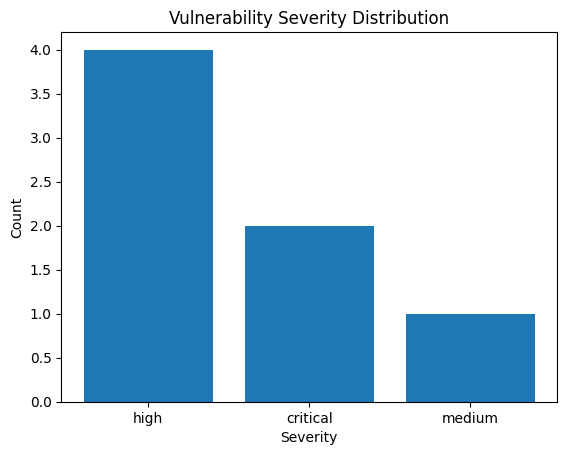

In [258]:
def vulnerability_chart(vuln_list):

    counts = {}

    for v in vuln_list:
        sev = v.severity.lower()
        counts[sev] = counts.get(sev, 0) + 1

    labels = list(counts.keys())
    values = list(counts.values())

    import matplotlib.pyplot as plt

    plt.bar(labels, values)
    plt.title("Vulnerability Severity Distribution")
    plt.xlabel("Severity")
    plt.ylabel("Count")
    plt.show()

vulnerability_chart(vulns)

In [259]:
asset_df.to_csv("assets_report.csv", index=False)
vuln_df.to_csv("vulnerability_report.csv", index=False)
findings_df.to_csv("findings_report.csv", index=False)
alerts_df.to_csv("detection_alerts_report.csv", index=False)
attack_path_df.to_csv("attack_paths_report.csv", index=False)

print("CSV reports exported successfully.")

CSV reports exported successfully.


In [260]:
report_data = {
    "assets": [asdict(a) for a in assets],
    "vulnerabilities": [asdict(v) for v in vulns],
    "artifacts": [asdict(a) for a in artifacts],
    "iocs": [asdict(i) for i in iocs],
    "findings": [asdict(f) for f in findings],
    "attack_paths": [
        {
            "path_id": p.path_id,
            "name": p.name,
            "objective": p.objective,
            "likelihood": p.likelihood,
            "impact": p.impact,
            "risk": p.overall_risk
        }
        for p in attack_paths
    ],
    "alerts": [asdict(a) for a in detection_alerts]
}

with open("security_assessment_report.json", "w") as f:
    json.dump(report_data, f, indent=2)

print("Full JSON security report exported.")

Full JSON security report exported.


## 27. Executive Summary

This project simulated a controlled cybersecurity assessment using a combination of reconnaissance, vulnerability enumeration, detection engineering, and attack path analysis.

Key outcomes include:

• identification of multiple exposed network services  
• discovery of vulnerabilities associated with remote access infrastructure  
• correlation of suspicious indicators of compromise  
• modeling of potential attack paths  
• implementation of a configurable detection rule framework  

The analysis identified several areas where security improvements would significantly reduce risk.

Primary recommendations include:

• patch vulnerable services  
• restrict unnecessary remote access  
• strengthen authentication controls  
• improve monitoring of suspicious indicators  
• tune detection rules to reduce false positives

## 28. Day 8 Notes

### Completed Work

• generated structured asset and vulnerability reports  
• created security dashboard metrics  
• visualized vulnerability severity distribution  
• exported CSV and JSON report artifacts  

### Importance

Clear reporting is essential in cybersecurity because technical findings must be communicated effectively to decision makers.

This reporting framework allows investigation results to be shared in a structured, repeatable format.

## 29. Security Posture Scorecard

This section summarizes the overall security posture of the simulated environment using a simple scoring model.

The purpose of the scorecard is to translate technical findings into a clear overall assessment.

Scoring considers:

- vulnerability exposure
- attack path risk
- suspicious indicators
- detection coverage
- false positive tuning

The resulting score is intended for classroom reporting and does not represent an industry-standard certification score.

In [261]:
def clamp(value, minimum=0, maximum=100):
    return max(minimum, min(value, maximum))

In [262]:
def score_vulnerability_hygiene(vuln_list: List[Vulnerability]) -> int:
    score = 100
    for v in vuln_list:
        sev = v.severity.lower()
        if sev == "critical":
            score -= 20
        elif sev == "high":
            score -= 12
        elif sev == "medium":
            score -= 6
        elif sev == "low":
            score -= 3
        else:
            score -= 1
    return clamp(score)


def score_attack_surface(asset_list: List[Asset], artifact_list: List[Artifact]) -> int:
    score = 100
    exposed_services = sum(1 for a in artifact_list if a.artifact_type == "service")
    external_assets = sum(1 for a in asset_list if a.asset_type in ["domain", "ip"])
    score -= exposed_services * 4
    score -= external_assets * 2
    return clamp(score)


def score_attack_path_risk(path_list: List[AttackPath]) -> int:
    score = 100
    for path in path_list:
        risk = path.overall_risk.lower()
        if risk == "critical":
            score -= 20
        elif risk == "high":
            score -= 12
        elif risk == "medium":
            score -= 7
        elif risk == "low":
            score -= 3
    return clamp(score)


def score_detection_coverage(rule_list: List[DetectionRule], alert_list: List[DetectionAlert]) -> int:
    enabled_rules = sum(1 for r in rule_list if r.enabled)
    if enabled_rules == 0:
        return 20
    score = 50 + enabled_rules * 10
    if len(alert_list) > 0:
        score += 10
    return clamp(score)


def score_false_positive_tuning() -> int:
    score = 60
    if "hrconnex.thm" in ALLOWLIST["domains"]:
        score += 20
    return clamp(score)

In [263]:
def generate_scorecard():
    return {
        "vulnerability_hygiene": score_vulnerability_hygiene(vulns),
        "attack_surface": score_attack_surface(assets, artifacts),
        "attack_path_risk": score_attack_path_risk(attack_paths),
        "detection_coverage": score_detection_coverage(detection_rules, detection_alerts),
        "false_positive_tuning": score_false_positive_tuning()
    }

In [264]:
def show_scorecard():
    print_section("SECURITY POSTURE SCORECARD")

    scorecard = generate_scorecard()
    for category, score in scorecard.items():
        print(f"{category}: {score}")

    overall = round(sum(scorecard.values()) / len(scorecard))
    print(f"\nOverall Security Posture Score: {overall}/100")

show_scorecard()


SECURITY POSTURE SCORECARD
vulnerability_hygiene: 6
attack_surface: 62
attack_path_risk: 68
detection_coverage: 100
false_positive_tuning: 80

Overall Security Posture Score: 63/100


In [265]:
def interpret_posture_score(score: int) -> str:
    if score >= 85:
        return "Strong"
    elif score >= 70:
        return "Moderate"
    elif score >= 50:
        return "Needs Improvement"
    return "High Risk"


scorecard = generate_scorecard()
overall_score = round(sum(scorecard.values()) / len(scorecard))
print("Posture Rating:", interpret_posture_score(overall_score))

Posture Rating: Needs Improvement


In [266]:
def scorecard_table():
    scorecard = generate_scorecard()
    rows = [{"category": k, "score": v} for k, v in scorecard.items()]
    df = pd.DataFrame(rows)
    display(df)
    return df

scorecard_df = scorecard_table()

,category,score
0,vulnerability_hygiene,6
1,attack_surface,62
2,attack_path_risk,68
3,detection_coverage,100
4,false_positive_tuning,80


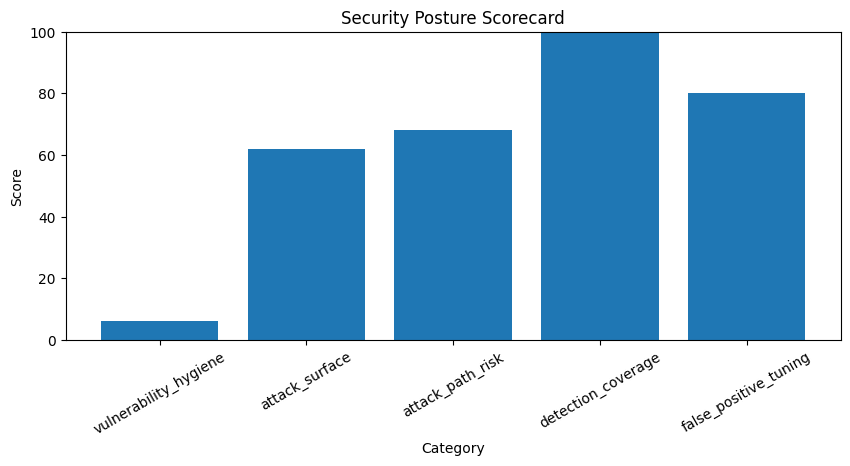

In [267]:
import matplotlib.pyplot as plt

def plot_scorecard():
    scorecard = generate_scorecard()
    labels = list(scorecard.keys())
    values = list(scorecard.values())

    plt.figure(figsize=(10, 4))
    plt.bar(labels, values)
    plt.title("Security Posture Scorecard")
    plt.xlabel("Category")
    plt.ylabel("Score")
    plt.ylim(0, 100)
    plt.xticks(rotation=30)
    plt.show()

plot_scorecard()

In [268]:
def posture_strengths_weaknesses():
    scorecard = generate_scorecard()

    strengths = [k for k, v in scorecard.items() if v >= 75]
    weaknesses = [k for k, v in scorecard.items() if v < 75]

    print_section("POSTURE SUMMARY")
    print("Strengths:")
    for s in strengths:
        print(f"  - {s}")

    print("\nWeaknesses:")
    for w in weaknesses:
        print(f"  - {w}")

posture_strengths_weaknesses()


POSTURE SUMMARY
Strengths:
  - detection_coverage
  - false_positive_tuning

Weaknesses:
  - vulnerability_hygiene
  - attack_surface
  - attack_path_risk


In [269]:
scorecard_df.to_csv("security_posture_scorecard.csv", index=False)
print("Exported security_posture_scorecard.csv")

Exported security_posture_scorecard.csv


## 30. Security Posture Scorecard Summary

A simplified scorecard was used to assess the overall security posture of the simulated environment.

### Scored Categories
- vulnerability hygiene
- attack surface
- attack path risk
- detection coverage
- false positive tuning

### Interpretation
The environment shows a mix of strengths and weaknesses.

Positive indicators include:
- detection engineering logic was implemented
- false positive tuning was demonstrated through allow-listing

Areas needing improvement include:
- exposed remote access services
- high-risk vulnerabilities
- attack paths that could enable deeper compromise

The scorecard provides a concise way to summarize the environment for leadership-style reporting.

## 31. Day 9 Notes

### Completed Work
- built a security posture scorecard
- calculated category-level security scores
- generated an overall posture score
- created a posture visualization
- exported scorecard results to CSV

### Importance
This phase helps translate technical findings into a high-level risk summary that is easier for non-technical stakeholders to understand.

In [270]:
# Add Vulnversity target

add_ip(
    assets,
    "10.10.xx.xx",   # replace with your real machine IP
    notes="TryHackMe Vulnversity lab machine"
)

show_assets(assets)


ASSETS
A1 | domain | vpn.mockorg.local | Lab VPN portal
A2 | host   | mail.mockorg.local | Lab mail server
A3 | ip     | 192.168.56.10 | Web app VM
A4 | domain | portal.mockorg.local | Employee portal
A5 | domain | mail.mockorg.local | Mail access portal
A6 | host   | intranet.mockorg.local | Internal documentation portal
A7 | ip     | 192.168.56.25 | Possible mail server IP
A8 | ip     | 192.168.56.30 | Possible VPN endpoint IP
A9 | ip     | 10.64.189.206 | TryHackMe Nmap lab target host
A10 | ip     | 10.10.xx.xx | TryHackMe Vulnversity lab machine


In [271]:
add_artifact(
    artifacts,
    artifact_id=f"AR{len(artifacts)+1}",
    artifact_type="service",
    value="http:3333",
    notes="Web server discovered during Vulnversity enumeration"
)

add_artifact(
    artifacts,
    artifact_id=f"AR{len(artifacts)+1}",
    artifact_type="service",
    value="proxy:3128",
    notes="Squid 4.10 proxy detected"
)

show_artifacts(artifacts)


ARTIFACTS
AR1 | domain | vpn.mockorg.local | related_asset=A1 | Remote access portal
AR2 | domain | mail.mockorg.local | related_asset=A2 | Mail portal
AR3 | ip | 192.168.56.25 | related_asset=A4 | Mail server IP
AR4 | file_hash | 45cc5dd1c03e2dd598dcf11fcacd1934e69668002e27670fc0f3fbe0267519d5 | related_asset=None | Sample attachment hash
AR5 | domain | hrconnex.thm | related_asset=None | Authorized HR onboarding partner domain identified during SOC investigation
AR6 | service | ssh:22 | related_asset=A6 | OpenSSH 8.2p1 detected via Nmap
AR7 | service | http:80 | related_asset=A6 | Python WebSockify service detected
AR8 | service | http:81 | related_asset=A6 | Apache HTTP server detected
AR9 | service | ldap:389 | related_asset=A6 | OpenLDAP directory service detected
AR10 | service | rdp:3389 | related_asset=A6 | Remote Desktop service detected
AR11 | service | vnc:5901 | related_asset=A6 | VNC remote desktop service detected
AR12 | service | http:3333 | related_asset=None | Web ser

In [272]:
add_artifact(
    artifacts,
    artifact_id=f"AR{len(artifacts)+1}",
    artifact_type="directory",
    value="/internal/",
    notes="Hidden directory discovered via GoBuster"
)

add_finding(
    findings,
    finding_id=f"F{len(findings)+1}",
    category="recon",
    title="Hidden web directory discovered",
    severity="medium",
    description="Directory enumeration revealed the /internal/ endpoint.",
    evidence="GoBuster scan results",
    recommendation="Restrict access to administrative directories and disable directory indexing."
)

show_findings(findings)


FINDINGS
F1 | recon | medium | Externally identifiable VPN portal
F2 | recon | medium | Mail portal increases phishing attack surface
F3 | recon | info | Web application host identified
F4 | ioc | high | IOC match detected for domain
F5 | ioc | high | IOC match detected for file_hash
F6 | attack_path | high | High-risk attack path identified: Phishing to Mail Access
F7 | attack_path | critical | High-risk attack path identified: Web Exploitation to Internal Compromise
F8 | training_lab | medium | Phishing attack simulation demonstrates credential harvesting risk
F9 | soc_investigation | info | Suspicious external email link alert investigated
F10 | detection | low | Detection alert generated: Remote Access Portal Detection
F11 | detection | medium | Detection alert generated: Suspicious Mail Domain
F12 | detection | high | Detection alert generated: Known Malicious Attachment Hash
F13 | recon | high | Multiple remote access services exposed
F14 | recon | medium | Hidden web directory 

In [273]:
add_vulnerability(
    vulns,
    asset_id="A7",
    cve="CWE-434",
    severity="critical",
    description="Unrestricted file upload vulnerability",
    evidence="Upload filter bypassed using .phtml extension"
)

show_vulns(vulns)


VULNERABILITIES
A3 | CVE-2023-1234 | high | Outdated web framework
A3 | CVE-2021-41773 | high | Apache path traversal vulnerability
A4 | CVE-2019-0708 | critical | Remote Desktop Services vulnerability (BlueKeep)
A5 | CVE-2020-1472 | critical | Netlogon elevation of privilege vulnerability
A6 | CVE-2019-0708 | high | Remote Desktop services exposed to network
A6 | CVE-2015-5600 | medium | SSH brute-force risk
A6 | CVE-2020-25709 | high | LDAP directory exposure risk
A7 | CWE-434 | critical | Unrestricted file upload vulnerability


In [274]:
add_finding(
    findings,
    finding_id=f"F{len(findings)+1}",
    category="exploitation",
    title="Web upload vulnerability exploited",
    severity="critical",
    description="Attacker uploaded a PHP reverse shell through the vulnerable file upload mechanism.",
    evidence="Execution of reverse shell via uploaded .phtml file.",
    recommendation="Implement strict file upload validation and disable executable uploads."
)

Finding(finding_id='F15', category='exploitation', title='Web upload vulnerability exploited', severity='critical', related_asset_id=None, description='Attacker uploaded a PHP reverse shell through the vulnerable file upload mechanism.', evidence='Execution of reverse shell via uploaded .phtml file.', recommendation='Implement strict file upload validation and disable executable uploads.')

In [275]:
add_vulnerability(
    vulns,
    asset_id="A7",
    cve="CWE-250",
    severity="critical",
    description="Misconfigured SUID binary allowing privilege escalation",
    evidence="SUID bit set on /bin/systemctl"
)

add_finding(
    findings,
    finding_id=f"F{len(findings)+1}",
    category="privilege_escalation",
    title="Privilege escalation via SUID misconfiguration",
    severity="critical",
    description="The /bin/systemctl binary had SUID permissions, allowing escalation to root.",
    evidence="Privilege escalation observed during Vulnversity exploitation.",
    recommendation="Remove SUID permissions from unnecessary binaries and enforce least privilege."
)

show_findings(findings)


FINDINGS
F1 | recon | medium | Externally identifiable VPN portal
F2 | recon | medium | Mail portal increases phishing attack surface
F3 | recon | info | Web application host identified
F4 | ioc | high | IOC match detected for domain
F5 | ioc | high | IOC match detected for file_hash
F6 | attack_path | high | High-risk attack path identified: Phishing to Mail Access
F7 | attack_path | critical | High-risk attack path identified: Web Exploitation to Internal Compromise
F8 | training_lab | medium | Phishing attack simulation demonstrates credential harvesting risk
F9 | soc_investigation | info | Suspicious external email link alert investigated
F10 | detection | low | Detection alert generated: Remote Access Portal Detection
F11 | detection | medium | Detection alert generated: Suspicious Mail Domain
F12 | detection | high | Detection alert generated: Known Malicious Attachment Hash
F13 | recon | high | Multiple remote access services exposed
F14 | recon | medium | Hidden web directory 

In [276]:
path_vulnversity = AttackPath(
    path_id="AP3",
    name="Web Upload to Root Access",
    objective="Gain root access through web upload vulnerability",
    steps=[
        AttackStep(
            step_number=1,
            technique="Directory Enumeration",
            source="External attacker",
            target="/internal/",
            description="Hidden directory discovered via GoBuster.",
            risk="medium"
        ),
        AttackStep(
            step_number=2,
            technique="File Upload Exploit",
            source="Attacker",
            target="Web application",
            description="Upload filter bypassed using .phtml extension.",
            risk="high"
        ),
        AttackStep(
            step_number=3,
            technique="Remote Shell",
            source="Uploaded reverse shell",
            target="Web server",
            description="Attacker gained command execution.",
            risk="high"
        ),
        AttackStep(
            step_number=4,
            technique="Privilege Escalation",
            source="SUID misconfiguration",
            target="root user",
            description="Misconfigured /bin/systemctl allowed root access.",
            risk="critical"
        )
    ],
    likelihood="high",
    impact="critical",
    overall_risk="critical"
)

attack_paths.append(path_vulnversity)

show_attack_paths(attack_paths)


ATTACK PATHS
AP1 | Phishing to Mail Access
Objective: Obtain user credentials and access internal resources
Likelihood: medium | Impact: high | Overall Risk: high
  Step 1: Reconnaissance
    Source: External actor
    Target: mail.mockorg.local
    Description: Mail-related infrastructure identified during recon.
    Risk: medium
  Step 2: Phishing Delivery
    Source: Suspicious domain / phishing infrastructure
    Target: User credentials
    Description: IOC overlap suggests potential phishing-related exposure.
    Risk: high
  Step 3: Credential Access
    Source: Compromised credentials
    Target: vpn.mockorg.local
    Description: Captured credentials could be reused against remote access systems.
    Risk: high
  Step 4: Initial Access
    Source: VPN access
    Target: Internal environment
    Description: Valid credentials could allow internal access if MFA is weak or absent.
    Risk: high
--------------------------------------------------------------------------------
AP2

## Vulnversity Lab Exercise

A vulnerable web application environment was analyzed using the TryHackMe Vulnversity lab.

### Enumeration

Network scanning revealed several open services, including a web server running on port 3333 and a Squid proxy.

Directory enumeration identified a hidden endpoint:

/internal/

### Exploitation

The web application allowed file uploads. The upload filter was bypassed using a .phtml extension, allowing execution of a PHP reverse shell.

### Privilege Escalation

After gaining shell access, a misconfigured SUID permission on the systemctl binary allowed escalation to root privileges.

### Security Lessons

This exercise demonstrates how multiple weaknesses can be chained together:

1. exposed services
2. directory discovery
3. unrestricted file upload
4. privilege escalation

These weaknesses combined to allow full system compromise.

In [277]:
show_asset_risk(assets, vulns)
show_environment_risk(vulns, attack_paths)


ASSET RISK SCORES
A1 | vpn.mockorg.local | Risk Score: 0
A2 | mail.mockorg.local | Risk Score: 0
A3 | 192.168.56.10 | Risk Score: 16
A4 | portal.mockorg.local | Risk Score: 10
A5 | mail.mockorg.local | Risk Score: 10
A6 | intranet.mockorg.local | Risk Score: 21
A7 | 192.168.56.25 | Risk Score: 20
A8 | 192.168.56.30 | Risk Score: 0
A9 | 10.64.189.206 | Risk Score: 0
A10 | 10.10.xx.xx | Risk Score: 0

OVERALL ENVIRONMENT RISK
Total Risk Score: 147
Environment Risk Rating: CRITICAL


## 32. Security Remediation Roadmap

The remediation roadmap translates the technical findings identified during this assessment into actionable security improvements.

The roadmap prioritizes security actions based on:

• vulnerability severity  
• likelihood of exploitation  
• potential business impact  

The goal is to reduce risk while improving the overall security posture of the environment.

## 32. Security Remediation Roadmap

The remediation roadmap translates the technical findings identified during this assessment into actionable security improvements.

The roadmap prioritizes security actions based on:

• vulnerability severity  
• likelihood of exploitation  
• potential business impact  

The goal is to reduce risk while improving the overall security posture of the environment.

In [278]:
REMEDIATION_PRIORITY = {
    "critical": 1,
    "high": 2,
    "medium": 3,
    "low": 4,
    "info": 5
}

In [279]:
def generate_remediation_list(vuln_list):

    remediation_items = []

    for v in vuln_list:
        remediation_items.append({
            "asset_id": v.asset_id,
            "vulnerability": v.cve,
            "severity": v.severity,
            "priority": REMEDIATION_PRIORITY.get(v.severity.lower(), 5),
            "recommended_fix": v.description
        })

    remediation_items.sort(key=lambda x: x["priority"])

    return remediation_items

In [280]:
def show_remediation_plan():

    print_section("REMEDIATION ROADMAP")

    items = generate_remediation_list(vulns)

    for item in items:
        print(
            f"Priority {item['priority']} → "
            f"{item['vulnerability']} | "
            f"{item['severity']} | "
            f"Asset {item['asset_id']}"
        )

show_remediation_plan()


REMEDIATION ROADMAP
Priority 1 → CVE-2019-0708 | critical | Asset A4
Priority 1 → CVE-2020-1472 | critical | Asset A5
Priority 1 → CWE-434 | critical | Asset A7
Priority 1 → CWE-250 | critical | Asset A7
Priority 2 → CVE-2023-1234 | high | Asset A3
Priority 2 → CVE-2021-41773 | high | Asset A3
Priority 2 → CVE-2019-0708 | high | Asset A6
Priority 2 → CVE-2020-25709 | high | Asset A6
Priority 3 → CVE-2015-5600 | medium | Asset A6


In [281]:
def remediation_table():

    items = generate_remediation_list(vulns)

    df = pd.DataFrame(items)

    display(df)

    return df

remediation_df = remediation_table()

,asset_id,vulnerability,severity,priority,recommended_fix
0,A4,CVE-2019-0708,critical,1,Remote Desktop Services vulnerability (BlueKeep)
1,A5,CVE-2020-1472,critical,1,Netlogon elevation of privilege vulnerability
2,A7,CWE-434,critical,1,Unrestricted file upload vulnerability
3,A7,CWE-250,critical,1,Misconfigured SUID binary allowing privilege e...
4,A3,CVE-2023-1234,high,2,Outdated web framework
5,A3,CVE-2021-41773,high,2,Apache path traversal vulnerability
6,A6,CVE-2019-0708,high,2,Remote Desktop services exposed to network
7,A6,CVE-2020-25709,high,2,LDAP directory exposure risk
8,A6,CVE-2015-5600,medium,3,SSH brute-force risk


In [282]:
def remediation_timeline(severity):

    if severity == "critical":
        return "Immediate (24-48 hours)"
    elif severity == "high":
        return "Short term (1-2 weeks)"
    elif severity == "medium":
        return "Medium term (1 month)"
    else:
        return "Planned maintenance"


def remediation_schedule():

    rows = []

    for v in vulns:
        rows.append({
            "asset": v.asset_id,
            "issue": v.cve,
            "severity": v.severity,
            "timeline": remediation_timeline(v.severity.lower())
        })

    df = pd.DataFrame(rows)

    print_section("REMEDIATION SCHEDULE")
    display(df)

    return df

remediation_schedule()


REMEDIATION SCHEDULE


,asset,issue,severity,timeline
0,A3,CVE-2023-1234,high,Short term (1-2 weeks)
1,A3,CVE-2021-41773,high,Short term (1-2 weeks)
2,A4,CVE-2019-0708,critical,Immediate (24-48 hours)
3,A5,CVE-2020-1472,critical,Immediate (24-48 hours)
4,A6,CVE-2019-0708,high,Short term (1-2 weeks)
5,A6,CVE-2015-5600,medium,Medium term (1 month)
6,A6,CVE-2020-25709,high,Short term (1-2 weeks)
7,A7,CWE-434,critical,Immediate (24-48 hours)
8,A7,CWE-250,critical,Immediate (24-48 hours)


,asset,issue,severity,timeline
0,A3,CVE-2023-1234,high,Short term (1-2 weeks)
1,A3,CVE-2021-41773,high,Short term (1-2 weeks)
2,A4,CVE-2019-0708,critical,Immediate (24-48 hours)
3,A5,CVE-2020-1472,critical,Immediate (24-48 hours)
4,A6,CVE-2019-0708,high,Short term (1-2 weeks)
5,A6,CVE-2015-5600,medium,Medium term (1 month)
6,A6,CVE-2020-25709,high,Short term (1-2 weeks)
7,A7,CWE-434,critical,Immediate (24-48 hours)
8,A7,CWE-250,critical,Immediate (24-48 hours)


In [283]:
def remediation_themes():

    print_section("SECURITY IMPROVEMENT THEMES")

    themes = [
        "Patch vulnerable services",
        "Restrict exposed remote access",
        "Improve authentication controls",
        "Implement stronger monitoring",
        "Reduce attack surface",
        "Improve detection engineering"
    ]

    for t in themes:
        print("•", t)

remediation_themes()


SECURITY IMPROVEMENT THEMES
• Patch vulnerable services
• Restrict exposed remote access
• Improve authentication controls
• Implement stronger monitoring
• Reduce attack surface
• Improve detection engineering


In [284]:
remediation_df.to_csv("remediation_roadmap.csv", index=False)
print("Remediation roadmap exported.")

Remediation roadmap exported.


## 33. Remediation Strategy

The analysis performed during this assessment revealed several areas where security improvements would significantly reduce risk.

### Immediate Actions

Critical vulnerabilities identified during the assessment should be addressed immediately.

These include:

• unrestricted file upload vulnerabilities  
• privilege escalation risks from misconfigured system permissions  
• exposed remote access services  

### Short-Term Improvements

Additional improvements should focus on strengthening defensive controls.

Examples include:

• patching vulnerable software  
• restricting unnecessary network services  
• improving authentication policies  

### Long-Term Security Enhancements

Long-term improvements should focus on strengthening detection and response capabilities.

Examples include:

• expanding detection rule coverage  
• improving alert triage workflows  
• reducing false positives through tuning

In [285]:
@dataclass
class MitreTechnique:
    technique_id: str
    name: str
    tactic: str
    description: str

In [286]:
mitre_techniques: List[MitreTechnique] = []

In [287]:
mitre_techniques.append(
    MitreTechnique(
        technique_id="T1595",
        name="Active Scanning",
        tactic="Reconnaissance",
        description="Nmap scanning used to identify open ports and services."
    )
)

mitre_techniques.append(
    MitreTechnique(
        technique_id="T1190",
        name="Exploit Public-Facing Application",
        tactic="Initial Access",
        description="File upload vulnerability exploited in the Vulnversity lab."
    )
)

mitre_techniques.append(
    MitreTechnique(
        technique_id="T1059",
        name="Command and Scripting Interpreter",
        tactic="Execution",
        description="Reverse shell executed through uploaded PHP file."
    )
)

mitre_techniques.append(
    MitreTechnique(
        technique_id="T1068",
        name="Privilege Escalation",
        tactic="Privilege Escalation",
        description="Misconfigured SUID binary allowed root access."
    )
)

mitre_techniques.append(
    MitreTechnique(
        technique_id="T1566",
        name="Phishing",
        tactic="Initial Access",
        description="Phishing scenario investigated in TryHackMe SOC lab."
    )
)

In [288]:
def show_mitre_mapping():

    print_section("MITRE ATT&CK TECHNIQUES")

    for t in mitre_techniques:
        print(f"{t.technique_id} | {t.name}")
        print(f"  Tactic: {t.tactic}")
        print(f"  Description: {t.description}")
        print()

show_mitre_mapping()


MITRE ATT&CK TECHNIQUES
T1595 | Active Scanning
  Tactic: Reconnaissance
  Description: Nmap scanning used to identify open ports and services.

T1190 | Exploit Public-Facing Application
  Tactic: Initial Access
  Description: File upload vulnerability exploited in the Vulnversity lab.

T1059 | Command and Scripting Interpreter
  Tactic: Execution
  Description: Reverse shell executed through uploaded PHP file.

T1068 | Privilege Escalation
  Tactic: Privilege Escalation
  Description: Misconfigured SUID binary allowed root access.

T1566 | Phishing
  Tactic: Initial Access
  Description: Phishing scenario investigated in TryHackMe SOC lab.



In [289]:
def mitre_table():

    rows = [asdict(t) for t in mitre_techniques]

    df = pd.DataFrame(rows)

    display(df)

    return df

mitre_df = mitre_table()

,technique_id,name,tactic,description
0,T1595,Active Scanning,Reconnaissance,Nmap scanning used to identify open ports and ...
1,T1190,Exploit Public-Facing Application,Initial Access,File upload vulnerability exploited in the Vul...
2,T1059,Command and Scripting Interpreter,Execution,Reverse shell executed through uploaded PHP file.
3,T1068,Privilege Escalation,Privilege Escalation,Misconfigured SUID binary allowed root access.
4,T1566,Phishing,Initial Access,Phishing scenario investigated in TryHackMe SO...


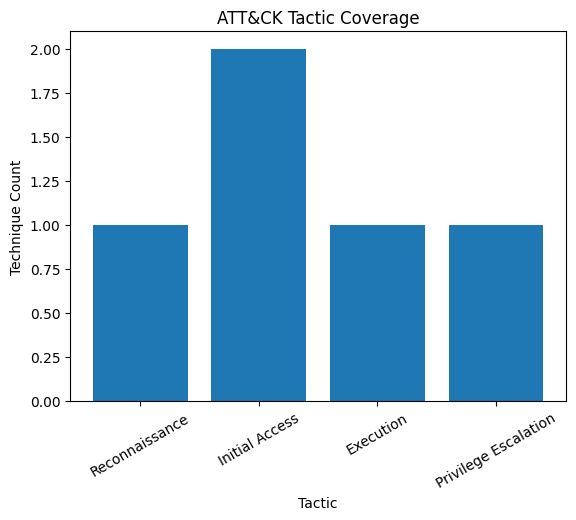

In [290]:
def mitre_tactic_chart():

    counts = {}

    for t in mitre_techniques:
        counts[t.tactic] = counts.get(t.tactic, 0) + 1

    labels = list(counts.keys())
    values = list(counts.values())

    import matplotlib.pyplot as plt

    plt.bar(labels, values)
    plt.title("ATT&CK Tactic Coverage")
    plt.xlabel("Tactic")
    plt.ylabel("Technique Count")
    plt.xticks(rotation=30)
    plt.show()

mitre_tactic_chart()

In [291]:
def mitre_gap_analysis():

    print_section("ATT&CK GAP ANALYSIS")

    covered = {t.technique_id for t in mitre_techniques}

    key_techniques = [
        "T1078",  # valid accounts
        "T1046",  # network scanning
        "T1055",  # process injection
        "T1021"   # remote services
    ]

    for technique in key_techniques:
        if technique not in covered:
            print(f"Detection gap identified: {technique}")

mitre_gap_analysis()


ATT&CK GAP ANALYSIS
Detection gap identified: T1078
Detection gap identified: T1046
Detection gap identified: T1055
Detection gap identified: T1021


In [292]:
mitre_df.to_csv("mitre_attack_mapping.csv", index=False)
print("MITRE ATT&CK mapping exported.")

MITRE ATT&CK mapping exported.


## 36. ATT&CK Technique Summary

The techniques observed during the assessment correspond to several phases of the MITRE ATT&CK lifecycle.

### Reconnaissance

Nmap scanning identified exposed services on the target host.

### Initial Access

A file upload vulnerability allowed execution of a malicious payload.

### Execution

A reverse shell was executed on the compromised web server.

### Privilege Escalation

A misconfigured SUID binary allowed escalation to root privileges.

### Social Engineering

A phishing scenario was investigated as part of the SOC simulation.

Mapping these activities to MITRE ATT&CK techniques provides a standardized way to describe attacker behavior and detection opportunities.

## 38. Threat Intelligence Correlation

Threat intelligence correlation enriches identified indicators with additional context.

This helps analysts determine:

• whether an indicator is malicious  
• how it has been used in past attacks  
• what techniques are associated with it  

This section simulates the use of threat intelligence feeds to enhance analysis.

In [293]:
@dataclass
class ThreatIntel:
    indicator: str
    indicator_type: str   # domain, ip, hash
    threat_type: str
    confidence: int
    source: str
    mitre_technique: str

In [294]:
threat_intel_feed: List[ThreatIntel] = []

In [295]:
threat_intel_feed.append(
    ThreatIntel(
        indicator="phishy-lookalike.net",
        indicator_type="domain",
        threat_type="phishing",
        confidence=90,
        source="Simulated Threat Feed",
        mitre_technique="T1566"
    )
)

threat_intel_feed.append(
    ThreatIntel(
        indicator="203.0.113.50",
        indicator_type="ip",
        threat_type="command_and_control",
        confidence=85,
        source="Simulated Threat Feed",
        mitre_technique="T1071"
    )
)

threat_intel_feed.append(
    ThreatIntel(
        indicator="45cc5dd1c03e2dd598dcf11fcacd1934e69668002e27670fc0f3fbe0267519d5",
        indicator_type="file_hash",
        threat_type="malware",
        confidence=95,
        source="Simulated Threat Feed",
        mitre_technique="T1059"
    )
)

In [296]:
def show_threat_intel():

    print_section("THREAT INTELLIGENCE FEED")

    for ti in threat_intel_feed:
        print(f"{ti.indicator} | {ti.indicator_type} | {ti.threat_type} | confidence={ti.confidence}")

show_threat_intel()


THREAT INTELLIGENCE FEED
phishy-lookalike.net | domain | phishing | confidence=90
203.0.113.50 | ip | command_and_control | confidence=85
45cc5dd1c03e2dd598dcf11fcacd1934e69668002e27670fc0f3fbe0267519d5 | file_hash | malware | confidence=95


In [297]:
def correlate_threat_intel(artifact_list, intel_feed):

    print_section("THREAT INTEL MATCHES")

    matches = []

    for artifact in artifact_list:
        for intel in intel_feed:

            if artifact.value.lower() == intel.indicator.lower():

                match = {
                    "artifact": artifact.value,
                    "type": artifact.artifact_type,
                    "threat": intel.threat_type,
                    "confidence": intel.confidence,
                    "mitre": intel.mitre_technique
                }

                matches.append(match)

                print(
                    f"MATCH → {artifact.value} | "
                    f"{intel.threat_type} | "
                    f"confidence={intel.confidence} | "
                    f"MITRE={intel.mitre_technique}"
                )

    if not matches:
        print("No threat intelligence matches found.")

    return matches

intel_matches = correlate_threat_intel(artifacts, threat_intel_feed)


THREAT INTEL MATCHES
MATCH → 45cc5dd1c03e2dd598dcf11fcacd1934e69668002e27670fc0f3fbe0267519d5 | malware | confidence=95 | MITRE=T1059


In [298]:
def add_threat_intel_findings(matches, finding_list):

    for match in matches:

        severity = "high" if match["confidence"] >= 90 else "medium"

        add_finding(
            finding_list,
            finding_id=f"F{len(finding_list)+1}",
            category="threat_intel",
            title="Threat intelligence match detected",
            severity=severity,
            description=f"Indicator {match['artifact']} matched known {match['threat']} infrastructure.",
            evidence=f"MITRE technique {match['mitre']}",
            recommendation="Investigate associated systems and block indicator if malicious."
        )

add_threat_intel_findings(intel_matches, findings)
show_findings(findings)


FINDINGS
F1 | recon | medium | Externally identifiable VPN portal
F2 | recon | medium | Mail portal increases phishing attack surface
F3 | recon | info | Web application host identified
F4 | ioc | high | IOC match detected for domain
F5 | ioc | high | IOC match detected for file_hash
F6 | attack_path | high | High-risk attack path identified: Phishing to Mail Access
F7 | attack_path | critical | High-risk attack path identified: Web Exploitation to Internal Compromise
F8 | training_lab | medium | Phishing attack simulation demonstrates credential harvesting risk
F9 | soc_investigation | info | Suspicious external email link alert investigated
F10 | detection | low | Detection alert generated: Remote Access Portal Detection
F11 | detection | medium | Detection alert generated: Suspicious Mail Domain
F12 | detection | high | Detection alert generated: Known Malicious Attachment Hash
F13 | recon | high | Multiple remote access services exposed
F14 | recon | medium | Hidden web directory 

In [299]:
def threat_intel_summary(matches):

    print_section("THREAT INTEL SUMMARY")

    print(f"Total Matches: {len(matches)}")

    threat_counts = {}

    for m in matches:
        threat_counts[m["threat"]] = threat_counts.get(m["threat"], 0) + 1

    for threat, count in threat_counts.items():
        print(f"{threat}: {count}")

threat_intel_summary(intel_matches)


THREAT INTEL SUMMARY
Total Matches: 1
malware: 1


In [300]:
def threat_intel_table():

    rows = [asdict(t) for t in threat_intel_feed]

    df = pd.DataFrame(rows)

    display(df)

    return df

threat_intel_df = threat_intel_table()

,indicator,indicator_type,threat_type,confidence,source,mitre_technique
0,phishy-lookalike.net,domain,phishing,90,Simulated Threat Feed,T1566
1,203.0.113.50,ip,command_and_control,85,Simulated Threat Feed,T1071
2,45cc5dd1c03e2dd598dcf11fcacd1934e69668002e2767...,file_hash,malware,95,Simulated Threat Feed,T1059


In [301]:
threat_intel_df.to_csv("threat_intel_feed.csv", index=False)
print("Threat intelligence feed exported.")

Threat intelligence feed exported.


## 39. Threat Intelligence Findings

Threat intelligence correlation identified potential overlaps between collected artifacts and known malicious indicators.

### Observations

• simulated phishing infrastructure was identified  
• a known malicious file hash was detected  
• potential command-and-control communication indicators were observed  

### Security Impact

Threat intelligence provides valuable context that helps prioritize investigation and response.

Indicators with high confidence scores should be treated as high priority for analysis and containment.

## 40. Day 12 Notes

### Completed Work

• added threat intelligence feed simulation  
• correlated indicators with collected artifacts  
• generated threat intelligence findings  
• mapped indicators to MITRE techniques  

### Importance

Threat intelligence allows security teams to move from reactive analysis to proactive threat detection and response.

## 41. Blue Team Detection & Log Analysis (SIEM)

The Blue Team log analysis exercise was completed to simulate real-world security monitoring and incident detection.

The analysis focused on:

• log correlation across multiple sources  
• identification of malicious activity  
• investigation of suspicious processes and connections  
• classification of attack techniques  

This section demonstrates defensive security capabilities using SIEM-based analysis.

In [302]:
siem_events = [
    {
        "type": "network_connection",
        "ip": "10.10.114.80",
        "process": "SharePoint.exe",
        "severity": "high",
        "description": "Suspicious outbound connection from host process"
    },
    {
        "type": "malware_hash",
        "hash": "770D14FFA142F09730B415506249E7D1",
        "severity": "critical",
        "description": "Known malicious MD5 hash identified"
    },
    {
        "type": "persistence",
        "task": "Office365 Install",
        "severity": "high",
        "description": "Scheduled task used for persistence"
    },
    {
        "type": "privilege_escalation",
        "user": "jack-brown",
        "severity": "critical",
        "description": "User escalated privileges to root"
    },
    {
        "type": "remote_access",
        "ip": "10.14.94.82",
        "failed_attempts": 4,
        "severity": "high",
        "description": "Multiple failed logins before successful access"
    },
    {
        "type": "web_attack",
        "uri": "/wp-login.php",
        "source_ip": "10.10.243.134",
        "tool": "WPScan",
        "attack_type": "brute_force",
        "severity": "high"
    }
]

In [303]:
def show_siem_events(events):

    print_section("SIEM DETECTION RESULTS")

    for e in events:
        print(f"{e['type']} → severity={e['severity']}")
        print(f"  details: {e}")
        print()

show_siem_events(siem_events)


SIEM DETECTION RESULTS
network_connection → severity=high
  details: {'type': 'network_connection', 'ip': '10.10.114.80', 'process': 'SharePoint.exe', 'severity': 'high', 'description': 'Suspicious outbound connection from host process'}

malware_hash → severity=critical
  details: {'type': 'malware_hash', 'hash': '770D14FFA142F09730B415506249E7D1', 'severity': 'critical', 'description': 'Known malicious MD5 hash identified'}

persistence → severity=high
  details: {'type': 'persistence', 'task': 'Office365 Install', 'severity': 'high', 'description': 'Scheduled task used for persistence'}

privilege_escalation → severity=critical
  details: {'type': 'privilege_escalation', 'user': 'jack-brown', 'severity': 'critical', 'description': 'User escalated privileges to root'}

remote_access → severity=high
  details: {'type': 'remote_access', 'ip': '10.14.94.82', 'failed_attempts': 4, 'severity': 'high', 'description': 'Multiple failed logins before successful access'}

web_attack → severit

In [304]:
def add_siem_findings(events, finding_list):

    for e in events:

        add_finding(
            finding_list,
            finding_id=f"F{len(finding_list)+1}",
            category="blue_team",
            title=f"SIEM detected {e['type']}",
            severity=e["severity"],
            description=e.get("description", "N/A"),
            evidence=str(e),
            recommendation="Investigate affected systems and apply containment measures."
        )

add_siem_findings(siem_events, findings)
show_findings(findings)


FINDINGS
F1 | recon | medium | Externally identifiable VPN portal
F2 | recon | medium | Mail portal increases phishing attack surface
F3 | recon | info | Web application host identified
F4 | ioc | high | IOC match detected for domain
F5 | ioc | high | IOC match detected for file_hash
F6 | attack_path | high | High-risk attack path identified: Phishing to Mail Access
F7 | attack_path | critical | High-risk attack path identified: Web Exploitation to Internal Compromise
F8 | training_lab | medium | Phishing attack simulation demonstrates credential harvesting risk
F9 | soc_investigation | info | Suspicious external email link alert investigated
F10 | detection | low | Detection alert generated: Remote Access Portal Detection
F11 | detection | medium | Detection alert generated: Suspicious Mail Domain
F12 | detection | high | Detection alert generated: Known Malicious Attachment Hash
F13 | recon | high | Multiple remote access services exposed
F14 | recon | medium | Hidden web directory 

In [305]:
add_detection_rule(
    detection_rules,
    rule_id="DR5",
    name="Suspicious Process Network Connection",
    description="Detect unusual outbound connections from internal processes",
    artifact_type="process",
    match_type="contains",
    pattern="SharePoint.exe",
    severity="high"
)

add_detection_rule(
    detection_rules,
    rule_id="DR6",
    name="Brute Force Login Detection",
    description="Detect repeated failed login attempts followed by success",
    artifact_type="auth",
    match_type="threshold",
    pattern="failed_login > 3",
    severity="high"
)

add_detection_rule(
    detection_rules,
    rule_id="DR7",
    name="Web Brute Force Detection",
    description="Detect repeated requests to login endpoints",
    artifact_type="web",
    match_type="contains",
    pattern="/wp-login.php",
    severity="high"
)

DetectionRule(rule_id='DR7', name='Web Brute Force Detection', description='Detect repeated requests to login endpoints', artifact_type='web', match_type='contains', pattern='/wp-login.php', severity='high', enabled=True, threshold=1)

In [306]:
def siem_summary(events):

    print_section("SIEM SUMMARY")

    print(f"Total Events: {len(events)}")

    severity_counts = {}

    for e in events:
        severity_counts[e["severity"]] = severity_counts.get(e["severity"], 0) + 1

    for s, count in severity_counts.items():
        print(f"{s}: {count}")

siem_summary(siem_events)


SIEM SUMMARY
Total Events: 6
high: 4
critical: 2


In [307]:
def siem_table(events):

    df = pd.DataFrame(events)
    display(df)

    return df

siem_df = siem_table(siem_events)

,type,ip,process,severity,description,hash,task,user,failed_attempts,uri,source_ip,tool,attack_type
0,network_connection,10.10.114.80,SharePoint.exe,high,Suspicious outbound connection from host process,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,malware_hash,NaN,NaN,critical,Known malicious MD5 hash identified,770D14FFA142F09730B415506249E7D1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,persistence,NaN,NaN,high,Scheduled task used for persistence,NaN,Office365 Install,NaN,NaN,NaN,NaN,NaN,NaN
3,privilege_escalation,NaN,NaN,critical,User escalated privileges to root,NaN,NaN,jack-brown,NaN,NaN,NaN,NaN,NaN
4,remote_access,10.14.94.82,NaN,high,Multiple failed logins before successful access,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
5,web_attack,NaN,NaN,high,NaN,NaN,NaN,NaN,NaN,/wp-login.php,10.10.243.134,WPScan,brute_force


In [308]:
siem_df.to_csv("siem_analysis.csv", index=False)
print("SIEM analysis exported.")

SIEM analysis exported.


## 42. Blue Team Analysis Summary

The SIEM-based analysis identified multiple indicators of compromise across host, network, and web logs.

### Key Findings

• suspicious outbound connection from SharePoint process  
• known malicious file hash detected  
• persistence mechanism via scheduled task  
• privilege escalation to root user  
• brute force login activity detected  
• web application brute force using WPScan  

### Attack Pattern Observed

The activity suggests a multi-stage attack involving:

initial access → persistence → privilege escalation → lateral movement → web exploitation  

### Defensive Insight

The analysis highlights the importance of:

• centralized logging  
• correlation across log sources  
• detection rule tuning  
• proactive monitoring  

The SIEM platform played a critical role in identifying and correlating these activities.

## 43. Day 13 Notes

### Completed Work

• integrated SIEM log analysis from TryHackMe  
• created structured event data  
• generated detection findings  
• improved detection rules  

### Importance

This section demonstrates real-world blue team capabilities including:

• log analysis  
• threat detection  
• incident investigation  

This significantly strengthens the overall project by adding defensive security perspective.

## 44. Day 14 Notes

### Completed Work

• created executive summary  
• defined assessment scope and methodology  
• documented attack paths  
• summarized overall risk  

### Importance

The executive report translates technical findings into a format that is understandable by leadership and decision-makers.

This is a critical component of any professional cybersecurity assessment.

## 45. Detection Rule Automation

Detection rule automation improves the efficiency of identifying malicious activity by applying structured logic to incoming data.

This section enhances the detection framework by:

• automating rule evaluation  
• introducing threshold-based detection  
• reducing false positives  
• simulating SIEM alert generation  

This reflects how modern security platforms process large volumes of log data in real time.

In [309]:
@dataclass
class DetectionRule:
    rule_id: str
    name: str
    description: str
    artifact_type: str
    match_type: str   # contains, equals, threshold
    pattern: str
    severity: str
    enabled: bool = True # Added back the 'enabled' parameter
    threshold: int = 1

In [310]:
def run_detection_engine(artifacts, rules):

    print_section("DETECTION ENGINE RESULTS")

    alerts = []

    for rule in rules:

        matches = []

        for artifact in artifacts:

            if artifact.artifact_type != rule.artifact_type:
                continue

            # MATCH TYPES
            if rule.match_type == "contains":
                if rule.pattern.lower() in artifact.value.lower():
                    matches.append(artifact)

            elif rule.match_type == "equals":
                if rule.pattern.lower() == artifact.value.lower():
                    matches.append(artifact)

        # THRESHOLD CHECK
        # Use getattr to safely access 'threshold' with a default of 1 if not present
        rule_threshold = getattr(rule, 'threshold', 1)
        if len(matches) >= rule_threshold:

            alert = {
                "rule": rule.name,
                "severity": rule.severity,
                "count": len(matches),
                "artifacts": [m.value for m in matches]
            }

            alerts.append(alert)

            print(f"ALERT: {rule.name}")
            print(f"  Severity: {rule.severity}")
            print(f"  Matches: {len(matches)}")
            print()

    if not alerts:
        print("No alerts triggered.")

    return alerts

alerts = run_detection_engine(artifacts, detection_rules)


DETECTION ENGINE RESULTS
ALERT: Suspicious Mail Domain
  Severity: medium
  Matches: 1

ALERT: Remote Access Portal Detection
  Severity: low
  Matches: 1



In [311]:
add_detection_rule(
    detection_rules,
    rule_id="DR8",
    name="Multiple Failed Logins",
    description="Detect brute-force login attempts",
    artifact_type="auth",
    match_type="contains",
    pattern="failed_login",
    severity="high",
    threshold=3
)

DetectionRule(rule_id='DR8', name='Multiple Failed Logins', description='Detect brute-force login attempts', artifact_type='auth', match_type='contains', pattern='failed_login', severity='high', enabled=True, threshold=3)

In [312]:
def show_alert_summary(alerts):

    print_section("ALERT SUMMARY")

    print(f"Total Alerts: {len(alerts)}")

    severity_counts = {}

    for a in alerts:
        severity_counts[a["severity"]] = severity_counts.get(a["severity"], 0) + 1

    for s, count in severity_counts.items():
        print(f"{s}: {count}")

show_alert_summary(alerts)


ALERT SUMMARY
Total Alerts: 2
medium: 1
low: 1


In [313]:
def alerts_table(alerts):

    df = pd.DataFrame(alerts)
    display(df)

    return df

alerts_df = alerts_table(alerts)

,rule,severity,count,artifacts
0,Suspicious Mail Domain,medium,1,[mail.mockorg.local]
1,Remote Access Portal Detection,low,1,[vpn.mockorg.local]


In [314]:
alerts_df.to_csv("detection_alerts.csv", index=False)
print("Detection alerts exported.")

Detection alerts exported.


In [315]:
def filter_false_positives(alerts):

    print_section("FILTERING FALSE POSITIVES")

    filtered = []

    for alert in alerts:

        # Example logic
        if "trusted-domain.com" in str(alert["artifacts"]):
            continue

        filtered.append(alert)

    print(f"Filtered Alerts: {len(filtered)}")

    return filtered

filtered_alerts = filter_false_positives(alerts)


FILTERING FALSE POSITIVES
Filtered Alerts: 2


## 46. Detection Automation Summary

The detection engine was enhanced to simulate automated alert generation based on defined rules.

### Improvements Implemented

• rule-based detection logic  
• threshold-based alert triggering  
• automated alert generation  
• false positive filtering  

### Security Impact

These improvements allow for:

• faster identification of threats  
• reduced analyst workload  
• improved accuracy of alerts  

Detection automation is a critical component of modern security operations centers.

## 47. Day 15 Notes

### Completed Work

• implemented automated detection engine  
• added threshold-based detection rules  
• generated alert outputs  
• reduced false positives  

### Importance

Automation enables security teams to handle large volumes of data efficiently while maintaining detection accuracy.

This step brings the project closer to real-world SIEM functionality.

## 48. Attack Path Visualization

This section visualizes potential attack paths within the environment.

Attack path visualization helps:

• understand how attackers move through systems  
• identify critical points of failure  
• communicate risk more effectively  

The visualization models attacker progression from initial access to full system compromise.

In [316]:
!pip install networkx matplotlib

In [317]:
import networkx as nx
import matplotlib.pyplot as plt

In [318]:
def build_attack_graph(attack_paths):

    G = nx.DiGraph()

    for path in attack_paths:

        previous_node = None

        for step in path.steps:

            node_label = f"{step.step_number}. {step.technique}"

            G.add_node(node_label)

            if previous_node:
                G.add_edge(previous_node, node_label)

            previous_node = node_label

    return G

In [319]:
def visualize_attack_graph(G):

    plt.figure(figsize=(12, 6))

    pos = nx.spring_layout(G)

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=3000,
        font_size=8
    )

    plt.title("Attack Path Visualization")
    plt.show()

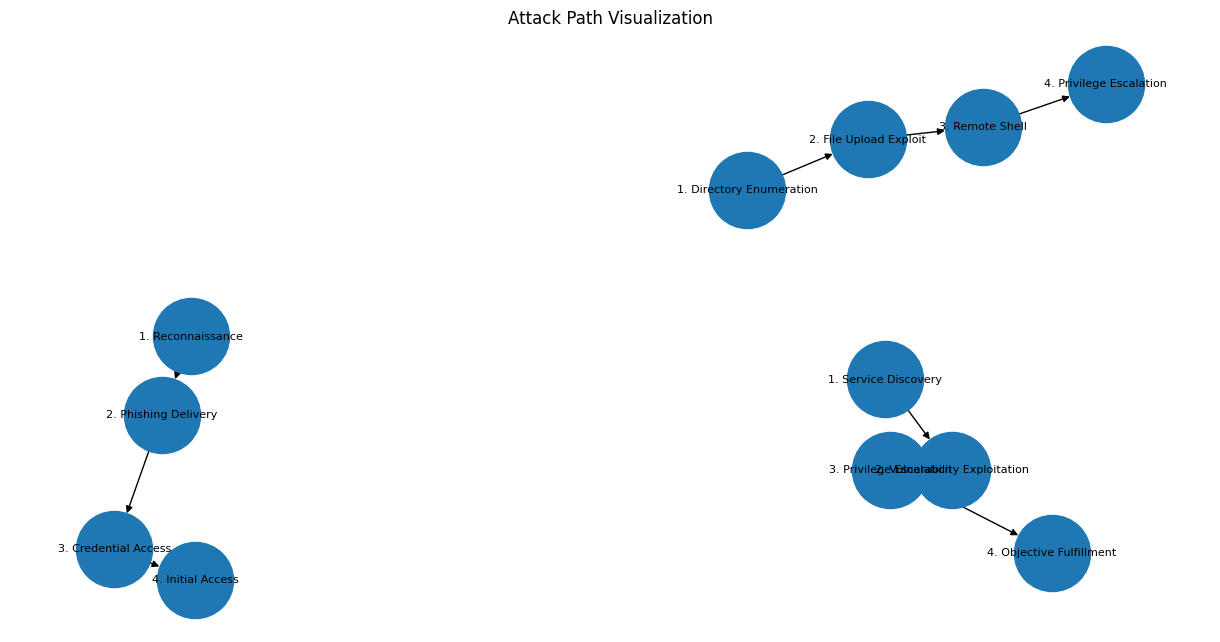

In [320]:
G = build_attack_graph(attack_paths)
visualize_attack_graph(G)

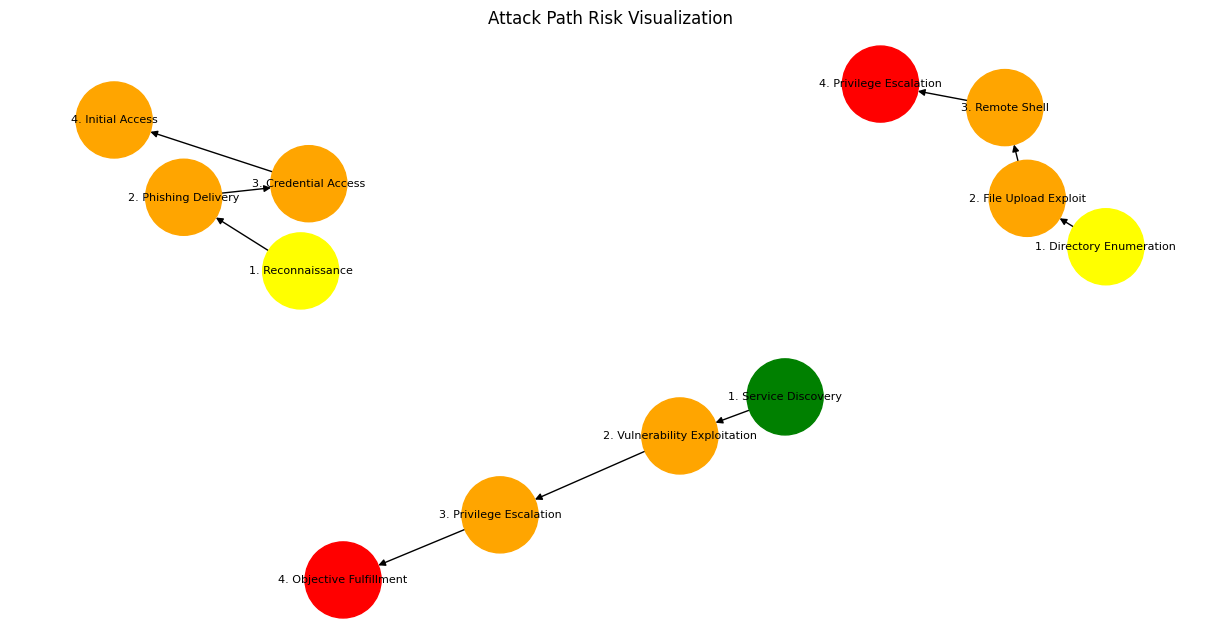

In [321]:
def visualize_risk_graph(attack_paths):

    G = nx.DiGraph()

    color_map = []

    for path in attack_paths:

        previous_node = None

        for step in path.steps:

            node_label = f"{step.step_number}. {step.technique}"
            G.add_node(node_label)

            # Color based on risk
            if step.risk.lower() == "critical":
                color_map.append("red")
            elif step.risk.lower() == "high":
                color_map.append("orange")
            elif step.risk.lower() == "medium":
                color_map.append("yellow")
            else:
                color_map.append("green")

            if previous_node:
                G.add_edge(previous_node, node_label)

            previous_node = node_label

    plt.figure(figsize=(12, 6))

    pos = nx.spring_layout(G)

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=color_map,
        node_size=3000,
        font_size=8
    )

    plt.title("Attack Path Risk Visualization")
    plt.show()

visualize_risk_graph(attack_paths)

In [322]:
def print_attack_flows():

    print_section("ATTACK PATH FLOWS")

    for path in attack_paths:
        print(f"\n{path.name}")
        for step in path.steps:
            print(f" → {step.technique} ({step.risk})")

print_attack_flows()


ATTACK PATH FLOWS

Phishing to Mail Access
 → Reconnaissance (medium)
 → Phishing Delivery (high)
 → Credential Access (high)
 → Initial Access (high)

Web Exploitation to Internal Compromise
 → Service Discovery (info)
 → Vulnerability Exploitation (high)
 → Privilege Escalation (high)
 → Objective Fulfillment (critical)

Web Upload to Root Access
 → Directory Enumeration (medium)
 → File Upload Exploit (high)
 → Remote Shell (high)
 → Privilege Escalation (critical)


## 49. Attack Path Analysis

The visualization illustrates how attackers can move through the environment by chaining together multiple weaknesses.

### Key Observations

• attackers can progress from initial access to full compromise  
• multiple high-risk steps exist in sequence  
• privilege escalation is a critical point of failure  

### Security Insight

Breaking any step in the attack chain can prevent full compromise.

For example:

• blocking file uploads  
• removing SUID misconfigurations  
• restricting remote access  

These controls significantly reduce attacker success.

## 50. Day 16 Notes

### Completed Work

• built attack path graph visualization  
• mapped attacker movement through systems  
• highlighted high-risk steps  

### Importance

Visualization helps communicate complex attack scenarios in a simple and effective way.

This is especially valuable when presenting findings to stakeholders.

In [323]:
print_section("FINAL METRICS")

print(f"Assets: {len(assets)}")
print(f"Vulnerabilities: {len(vulns)}")
print(f"Findings: {len(findings)}")
print(f"Detection Rules: {len(detection_rules)}")
print(f"Attack Paths: {len(attack_paths)}")


FINAL METRICS
Assets: 10
Vulnerabilities: 9
Findings: 23
Detection Rules: 8
Attack Paths: 3


In [324]:
from google.colab import files

files.download("vulnerability_report.csv")
files.download("detection_alerts.csv")
files.download("remediation_roadmap.csv")
files.download("security_assessment_report.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>